# Semantic-Class ROI Attention Analysis

Notebook per analizzare le attenzioni del modello sui **72 campioni test unici** (`average_test_repeats=True`) e confrontare:

- attenzione iniziale del `TokenMapper` (`query -> ROI`)
- attenzione del backbone Stable Audio composta con il mapper (`latent -> brain token -> ROI`)

L'obiettivo e' capire se una **classe semantica** come `speech` mostra una firma ROI gia' nel mapper e se questa firma cambia nel backbone.

In [16]:
# Se serve:
# !pip install diffusers transformers accelerate torchaudio seaborn pandas matplotlib --quiet

In [17]:
import os
import re
import math
import copy
import pickle
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from diffusers import StableAudioPipeline
from diffusers.models.embeddings import apply_rotary_emb
from diffusers.models.attention_processor import StableAudioAttnProcessor2_0
from diffusers.pipelines.stable_audio.pipeline_stable_audio import get_1d_rotary_pos_embed

from dataset import build_datasets, ROI_LIST
from model import AudioNeuroAdapter, StableAudioIPAttnProcessor2_0

sns.set_context('talk')
sns.set_style('whitegrid')
device = torch.device('cuda:6' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda:6


In [18]:
# Configurazione
DATA_PATH = '/srv/nfs-data/sisko/matteoc/maas_2023/pooled_data.pkl'
WAV_DIR = '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav'
SOUND_NAMES_PATH = '/home/matteoc/brainSounds/maas_data/SoundNames.npy'
CKPT_PATH = '/srv/nfs-data/sisko/matteoc/maas_2023/checkpoints/epoch_60.pt'

SPLIT = 'test'
AVERAGE_TEST_REPEATS = True
BATCH_SIZE = 4
NUM_WORKERS = 2
MAX_BATCHES = None

# Timesteps di probe nel backbone. Servono per vedere se il pattern cambia lungo il denoising.
PROBE_TIMESTEP_INDICES = [0, 10, 20, 30, 40, 50, 60, 70, 75, 80, 85, 90, 95, 99]  # 10 è il primo dopo l'input, 99 è l'ultimo

# Classe semantica da mettere in evidenza nei plot principali.
FOCUS_CLASS = 'animal'

SAVE_RESULTS = False
RESULTS_DIR = './attention_analysis_outputs_semantic'
os.makedirs(RESULTS_DIR, exist_ok=True)

In [19]:
def parse_semantic_class(sound_name: str) -> str:
    m = re.match(r'stim\d+_cat\d+_([a-zA-Z]+)_exemp\d+', str(sound_name))
    if m is None:
        raise ValueError(f'Impossibile estrarre la classe semantica da: {sound_name}')
    return m.group(1).lower()


def build_sound_metadata(sound_names: np.ndarray) -> pd.DataFrame:
    rows = []
    for idx, name in enumerate(sound_names):
        rows.append({
            'sound_idx': idx,
            'sound_name': str(name),
            'semantic_class': parse_semantic_class(str(name)),
        })
    return pd.DataFrame(rows)


def encode_audio_to_latents(vae, audio: torch.Tensor, device: torch.device) -> torch.Tensor:
    audio_in = audio.unsqueeze(1).to(device)
    audio_in = audio_in.expand(-1, 2, -1)
    with torch.no_grad():
        latents = vae.encode(audio_in).latent_dist.sample()
        scaling_factor = getattr(vae.config, 'scaling_factor', 1.0)
        latents = latents * scaling_factor
    return latents


def interpolation_matrix(in_len: int, out_len: int, device: torch.device) -> torch.Tensor:
    if in_len == out_len:
        return torch.eye(in_len, device=device)
    basis = torch.eye(in_len, device=device).unsqueeze(0)
    resized = F.interpolate(
        basis.transpose(1, 2),
        size=out_len,
        mode='linear',
        align_corners=False,
    ).transpose(1, 2)
    return resized.squeeze(0)


def get_brain_token_start_end(model: AudioNeuroAdapter, total_encoder_tokens: int):
    n_brain = model.audio_proj.out_len
    if model.conditioning_mode in {'brain_only', 'empty_prompt_plus_brain'}:
        return 0, n_brain
    if model.conditioning_mode == 'empty_prompt_ip_adapter':
        return None, None
    raise ValueError(f'conditioning_mode non supportata: {model.conditioning_mode}')


def load_model_and_data():
    ckpt = torch.load(CKPT_PATH, map_location=device)
    model_config = ckpt.get('model_config', {})

    stable_audio_id = model_config.get('stable_audio_id', 'stabilityai/stable-audio-open-1.0')
    num_decoder_queries = model_config.get('num_decoder_queries', 16)
    target_duration_s = model_config.get('target_duration_s', 1.0)
    target_sr = model_config.get('target_sr', 44100)
    conditioning_mode = model_config.get('conditioning_mode', 'brain_only')
    train_backbone_cross_attention = model_config.get('train_backbone_cross_attention', False)
    train_cross_attention_proj = model_config.get('train_cross_attention_proj', False)
    cv = model_config.get('cv', 'CV2')

    pipe = StableAudioPipeline.from_pretrained(stable_audio_id, torch_dtype=torch.float32).to(device)

    model = AudioNeuroAdapter(
        pipe=pipe,
        num_rois=len(ROI_LIST),
        max_voxels=1024,
        num_decoder_queries=num_decoder_queries,
        target_duration_s=target_duration_s,
        conditioning_mode=conditioning_mode,
        train_backbone_cross_attention=train_backbone_cross_attention,
        train_cross_attention_proj=train_cross_attention_proj,
    ).to(device)

    model.guidance_generator.load_state_dict(ckpt['guidance_generator'])
    model.audio_proj.load_state_dict(ckpt['audio_proj'])
    if ckpt.get('ip_adapter_scale') is not None:
        model.ip_adapter_scale.data.copy_(ckpt['ip_adapter_scale'].to(device=device, dtype=model.ip_adapter_scale.dtype))
    if ckpt.get('brain_prompt_scale') is not None:
        model.brain_prompt_scale.data.copy_(ckpt['brain_prompt_scale'].to(device=device, dtype=model.brain_prompt_scale.dtype))
    if model.ip_adapter_modules is not None and ckpt.get('ip_adapter_modules') is not None:
        model.ip_adapter_modules.load_state_dict(ckpt['ip_adapter_modules'])
    if train_backbone_cross_attention and ckpt.get('trainable_backbone') is not None:
        model.pipe.transformer.load_state_dict(ckpt['trainable_backbone'])
    if ckpt.get('_brain_norm_mean') is not None:
        model._brain_norm_mean = ckpt['_brain_norm_mean'].to(device)
        model._brain_norm_std = ckpt['_brain_norm_std'].to(device)
    model.eval()

    with open(DATA_PATH, 'rb') as f:
        pooled_data = pickle.load(f)
    sound_names = np.load(SOUND_NAMES_PATH, allow_pickle=True)
    sound_meta = build_sound_metadata(sound_names)

    saved_normalizer = model.get_brain_normalizer()
    train_ds, test_ds = build_datasets(
        pooled_data=pooled_data,
        cv=cv,
        wav_dir=WAV_DIR,
        sound_names=sound_names,
        target_sr=target_sr,
        target_len_s=target_duration_s,
        average_test_repeats=AVERAGE_TEST_REPEATS,
        brain_normalizer_override=saved_normalizer,
    )

    dataset = test_ds if SPLIT == 'test' else train_ds
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    return ckpt, model, loader, sound_meta


ckpt, model, loader, sound_meta = load_model_and_data()
print('conditioning_mode:', model.conditioning_mode)
print('Unique test sounds:', len(loader.dataset))
display(sound_meta['semantic_class'].value_counts().sort_index().rename('n_sounds').to_frame())

/tmp/ipykernel_1304808/2249361575.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Train: 1080 campioni | Test: 72 campioni
  brain_data shape: 6 ROI × 1024 voxels
  audio_target:     44100 samples @ 44100Hz (1.0s)
conditioning_mode: empty_prompt_ip_adapter
Unique test sounds: 72


,n_sounds
semantic_class,
animal,48
music,48
nature,48
speech,48
tools,48
voice,48


In [20]:
class MapperAttentionRecorder:
    def __init__(self, token_mapper):
        self.token_mapper = token_mapper
        self.handles = []
        self.records = []

    def _hook(self, module, inputs, output):
        if isinstance(output, tuple) and len(output) > 1 and output[1] is not None:
            self.records.append(output[1].detach().cpu())

    def __enter__(self):
        for layer in self.token_mapper.transformer.decoder.layers:
            self.handles.append(layer.multihead_attn.register_forward_hook(self._hook))
        return self

    def __exit__(self, exc_type, exc, tb):
        for h in self.handles:
            h.remove()
        self.handles = []

    def consume(self):
        if not self.records:
            return None
        stacked = torch.stack(self.records, dim=0)
        self.records = []
        return stacked


class AttentionStore:
    def __init__(self):
        self.cross = defaultdict(list)
        self.ip = defaultdict(list)

    def clear(self):
        self.cross.clear()
        self.ip.clear()


def _repeat_kv_to_all_heads(tensor: torch.Tensor, attn_heads: int) -> torch.Tensor:
    kv_heads = tensor.shape[1]
    if kv_heads == attn_heads:
        return tensor
    heads_per_kv_head = attn_heads // kv_heads
    return torch.repeat_interleave(tensor, heads_per_kv_head, dim=1, output_size=kv_heads * heads_per_kv_head)


def _attention_probs(query, key, attn_mask=None):
    scale = 1.0 / math.sqrt(query.shape[-1])
    scores = torch.matmul(query, key.transpose(-2, -1)) * scale
    if attn_mask is not None:
        scores = scores + attn_mask
    probs = torch.softmax(scores.float(), dim=-1).to(query.dtype)
    return probs


class RecordingStableAudioAttnProcessor2_0(nn.Module):
    def __init__(self, store: AttentionStore, name: str):
        super().__init__()
        self.store = store
        self.name = name

    def __call__(self, attn, hidden_states, encoder_hidden_states=None, attention_mask=None, rotary_emb=None):
        residual = hidden_states
        input_ndim = hidden_states.ndim

        if input_ndim == 4:
            batch_size, channel, height, width = hidden_states.shape
            hidden_states = hidden_states.view(batch_size, channel, height * width).transpose(1, 2)
        else:
            batch_size = hidden_states.shape[0]

        if encoder_hidden_states is None:
            encoder_hidden_states = hidden_states
        elif attn.norm_cross:
            encoder_hidden_states = attn.norm_encoder_hidden_states(encoder_hidden_states)

        sequence_length = encoder_hidden_states.shape[1]
        if attention_mask is not None:
            attention_mask = attn.prepare_attention_mask(attention_mask, sequence_length, batch_size)
            attention_mask = attention_mask.view(batch_size, attn.heads, -1, attention_mask.shape[-1])

        query = attn.to_q(hidden_states)
        key = attn.to_k(encoder_hidden_states)
        value = attn.to_v(encoder_hidden_states)

        head_dim = query.shape[-1] // attn.heads
        kv_heads = key.shape[-1] // head_dim

        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)

        key = _repeat_kv_to_all_heads(key, attn.heads)
        value = _repeat_kv_to_all_heads(value, attn.heads)

        if attn.norm_q is not None:
            query = attn.norm_q(query)
        if attn.norm_k is not None:
            key = attn.norm_k(key)

        if rotary_emb is not None:
            query_dtype = query.dtype
            key_dtype = key.dtype
            query = query.to(torch.float32)
            key = key.to(torch.float32)
            rot_dim = rotary_emb[0].shape[-1]
            query_to_rotate, query_unrotated = query[..., :rot_dim], query[..., rot_dim:]
            query_rotated = apply_rotary_emb(query_to_rotate, rotary_emb, use_real=True, use_real_unbind_dim=-2)
            query = torch.cat((query_rotated, query_unrotated), dim=-1)
            if not attn.is_cross_attention:
                key_to_rotate, key_unrotated = key[..., :rot_dim], key[..., rot_dim:]
                key_rotated = apply_rotary_emb(key_to_rotate, rotary_emb, use_real=True, use_real_unbind_dim=-2)
                key = torch.cat((key_rotated, key_unrotated), dim=-1)
            query = query.to(query_dtype)
            key = key.to(key_dtype)

        probs = _attention_probs(query, key, attention_mask)
        if attn.is_cross_attention:
            self.store.cross[self.name].append(probs.detach().cpu())

        hidden_states = torch.matmul(probs, value)
        hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)
        hidden_states = hidden_states.to(query.dtype)
        hidden_states = attn.to_out[0](hidden_states)
        hidden_states = attn.to_out[1](hidden_states)

        if input_ndim == 4:
            hidden_states = hidden_states.transpose(-1, -2).reshape(batch_size, channel, height, width)
        if attn.residual_connection:
            hidden_states = hidden_states + residual
        hidden_states = hidden_states / attn.rescale_output_factor
        return hidden_states


class RecordingStableAudioIPAttnProcessor2_0(nn.Module):
    def __init__(self, base_processor: StableAudioIPAttnProcessor2_0, store: AttentionStore, name: str):
        super().__init__()
        self.hidden_size = base_processor.hidden_size
        self.cross_attention_dim = base_processor.cross_attention_dim
        self.num_tokens = base_processor.num_tokens
        self.scale = base_processor.scale
        self.to_k_ip = copy.deepcopy(base_processor.to_k_ip)
        self.to_v_ip = copy.deepcopy(base_processor.to_v_ip)
        self.store = store
        self.name = name

    def __call__(self, attn, hidden_states, encoder_hidden_states=None, attention_mask=None, rotary_emb=None):
        residual = hidden_states
        input_ndim = hidden_states.ndim

        if input_ndim == 4:
            batch_size, channel, height, width = hidden_states.shape
            hidden_states = hidden_states.view(batch_size, channel, height * width).transpose(1, 2)
        else:
            batch_size = hidden_states.shape[0]

        if encoder_hidden_states is None:
            encoder_hidden_states = hidden_states
            ip_hidden_states = None
        else:
            if encoder_hidden_states.shape[1] < self.num_tokens:
                raise ValueError(f'Attesi almeno {self.num_tokens} token IP, ottenuti {encoder_hidden_states.shape[1]}.')
            split_idx = encoder_hidden_states.shape[1] - self.num_tokens
            encoder_hidden_states, ip_hidden_states = encoder_hidden_states[:, :split_idx, :], encoder_hidden_states[:, split_idx:, :]
            if attn.norm_cross:
                encoder_hidden_states = attn.norm_encoder_hidden_states(encoder_hidden_states)

        sequence_length = encoder_hidden_states.shape[1]
        if attention_mask is not None:
            attention_mask = attn.prepare_attention_mask(attention_mask, sequence_length, batch_size)
            attention_mask = attention_mask.view(batch_size, attn.heads, -1, attention_mask.shape[-1])

        query = attn.to_q(hidden_states)
        key = attn.to_k(encoder_hidden_states)
        value = attn.to_v(encoder_hidden_states)

        head_dim = query.shape[-1] // attn.heads
        kv_heads = key.shape[-1] // head_dim

        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)

        key = _repeat_kv_to_all_heads(key, attn.heads)
        value = _repeat_kv_to_all_heads(value, attn.heads)

        if attn.norm_q is not None:
            query = attn.norm_q(query)
        if attn.norm_k is not None:
            key = attn.norm_k(key)

        if rotary_emb is not None:
            query_dtype = query.dtype
            key_dtype = key.dtype
            query = query.to(torch.float32)
            key = key.to(torch.float32)
            rot_dim = rotary_emb[0].shape[-1]
            query_to_rotate, query_unrotated = query[..., :rot_dim], query[..., rot_dim:]
            query_rotated = apply_rotary_emb(query_to_rotate, rotary_emb, use_real=True, use_real_unbind_dim=-2)
            query = torch.cat((query_rotated, query_unrotated), dim=-1)
            if not attn.is_cross_attention:
                key_to_rotate, key_unrotated = key[..., :rot_dim], key[..., rot_dim:]
                key_rotated = apply_rotary_emb(key_to_rotate, rotary_emb, use_real=True, use_real_unbind_dim=-2)
                key = torch.cat((key_rotated, key_unrotated), dim=-1)
            query = query.to(query_dtype)
            key = key.to(key_dtype)

        probs = _attention_probs(query, key, attention_mask)
        if attn.is_cross_attention:
            self.store.cross[self.name].append(probs.detach().cpu())
        hidden_states_main = torch.matmul(probs, value)

        if ip_hidden_states is not None:
            ip_key = self.to_k_ip(ip_hidden_states)
            ip_value = self.to_v_ip(ip_hidden_states)
            ip_key = ip_key.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)
            ip_value = ip_value.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)
            ip_key = _repeat_kv_to_all_heads(ip_key, attn.heads)
            ip_value = _repeat_kv_to_all_heads(ip_value, attn.heads)
            if attn.norm_k is not None:
                ip_key = attn.norm_k(ip_key)
            ip_probs = _attention_probs(query, ip_key, None)
            self.store.ip[self.name].append(ip_probs.detach().cpu())
            hidden_states_ip = torch.matmul(ip_probs, ip_value)
            hidden_states = hidden_states_main + self.scale * hidden_states_ip
        else:
            hidden_states = hidden_states_main

        hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)
        hidden_states = hidden_states.to(query.dtype)
        hidden_states = attn.to_out[0](hidden_states)
        hidden_states = attn.to_out[1](hidden_states)

        if input_ndim == 4:
            hidden_states = hidden_states.transpose(-1, -2).reshape(batch_size, channel, height, width)
        if attn.residual_connection:
            hidden_states = hidden_states + residual
        hidden_states = hidden_states / attn.rescale_output_factor
        return hidden_states


def swap_in_recording_processors(model: AudioNeuroAdapter, store: AttentionStore):
    transformer = model.pipe.transformer
    original = copy.deepcopy(transformer.attn_processors)
    wrapped = {}
    for name, proc in transformer.attn_processors.items():
        if '.attn1.' in name:
            wrapped[name] = proc
        elif isinstance(proc, StableAudioIPAttnProcessor2_0):
            wrapped[name] = RecordingStableAudioIPAttnProcessor2_0(proc, store, name)
        else:
            wrapped[name] = RecordingStableAudioAttnProcessor2_0(store, name)
    transformer.set_attn_processor(wrapped)
    return original


def restore_processors(model: AudioNeuroAdapter, original_processors):
    model.pipe.transformer.set_attn_processor(original_processors)

In [21]:
@torch.no_grad()
def analyze_semantic_attention(model: AudioNeuroAdapter, loader: DataLoader, sound_meta: pd.DataFrame, max_batches=None):
    scheduler = model.pipe.scheduler
    scheduler.set_timesteps(100, device=device)
    available_timesteps = scheduler.timesteps.detach().cpu()
    timestep_indices = [idx for idx in PROBE_TIMESTEP_INDICES if idx < len(available_timesteps)]
    probe_timesteps = available_timesteps[timestep_indices]

    n_queries = model.guidance_generator.token_mapper.decoder_queries.num_embeddings
    n_brain_tokens = model.audio_proj.out_len
    query_to_projected = interpolation_matrix(n_queries, n_brain_tokens, device).detach().cpu()

    rows_mapper_roi = []
    rows_mapper_query_roi = []
    rows_backbone_roi = []
    rows_backbone_timestep_roi = []

    sound_meta_map = sound_meta.set_index('sound_idx')
    attn_store = AttentionStore()
    original_processors = swap_in_recording_processors(model, attn_store)

    try:
        for batch_idx, batch in enumerate(loader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            brain = batch['brain_data'].to(device)
            audio = batch['audio_target'].to(device)
            sound_idx = batch['sound_idx'].cpu().numpy()
            B = brain.shape[0]

            with MapperAttentionRecorder(model.guidance_generator.token_mapper) as mapper_rec:
                condition_tokens, _ = model.guidance_generator(brain)
            mapper_attn = mapper_rec.consume()
            if mapper_attn is None:
                raise RuntimeError('Non sono riuscito a catturare l\'attenzione del TokenMapper.')

            mapper_attn = mapper_attn.mean(dim=0)
            if mapper_attn.ndim == 4:
                mapper_attn = mapper_attn.mean(dim=1)

            mapper_projected = torch.einsum('tq,bqr->btr', query_to_projected, mapper_attn.cpu())
            encoder_hidden_states, global_hidden_states = model.build_conditioning(brain, device=device)
            latents = encode_audio_to_latents(model.pipe.vae, audio, device=device)

            for i in range(B):
                meta = sound_meta_map.loc[int(sound_idx[i])]
                sample_mapper = mapper_attn[i]
                sample_mapper_roi = sample_mapper.mean(dim=0).numpy()

                row = {
                    'sound_idx': int(sound_idx[i]),
                    'sound_name': meta['sound_name'],
                    'semantic_class': meta['semantic_class'],
                }
                for roi_name, value in zip(ROI_LIST, sample_mapper_roi):
                    row[roi_name] = float(value)
                rows_mapper_roi.append(row)

                for q in range(sample_mapper.shape[0]):
                    row_q = {
                        'sound_idx': int(sound_idx[i]),
                        'sound_name': meta['sound_name'],
                        'semantic_class': meta['semantic_class'],
                        'query_idx': q,
                    }
                    for roi_name, value in zip(ROI_LIST, sample_mapper[q].numpy()):
                        row_q[roi_name] = float(value)
                    rows_mapper_query_roi.append(row_q)

            for t_idx, t in zip(timestep_indices, probe_timesteps):
                attn_store.clear()
                timestep = t.to(device).unsqueeze(0).expand(B)
                noise = torch.randn_like(latents)
                noisy_latents = scheduler.add_noise(latents, noise, timestep)
                latent_input = scheduler.scale_model_input(noisy_latents, t.to(device))

                rotary_embedding = get_1d_rotary_pos_embed(
                    model.pipe.rotary_embed_dim,
                    latent_input.shape[2] + global_hidden_states.shape[1],
                    use_real=True,
                    repeat_interleave_real=False,
                )
                rotary_embedding = tuple(r.to(device) for r in rotary_embedding)

                _ = model.pipe.transformer(
                    hidden_states=latent_input,
                    timestep=timestep,
                    encoder_hidden_states=encoder_hidden_states,
                    global_hidden_states=global_hidden_states,
                    rotary_embedding=rotary_embedding,
                    return_dict=False,
                )[0]

                bank = attn_store.ip if model.conditioning_mode == 'empty_prompt_ip_adapter' else attn_store.cross
                if not bank:
                    continue

                layer_tensors = []
                for _, tensors in sorted(bank.items()):
                    if not tensors:
                        continue
                    layer_probs = torch.stack(tensors, dim=0).mean(dim=0)
                    if model.conditioning_mode != 'empty_prompt_ip_adapter':
                        start_end = get_brain_token_start_end(model, layer_probs.shape[-1])
                        if start_end[0] is None:
                            continue
                        start, end = start_end
                        layer_probs = layer_probs[..., start:end]
                    layer_tensors.append(layer_probs)

                if not layer_tensors:
                    continue

                backbone_attn = torch.stack(layer_tensors, dim=0).mean(dim=0)
                backbone_attn = backbone_attn.mean(dim=1)
                transported = torch.einsum('blt,btr->blr', backbone_attn.cpu(), mapper_projected)

                for i in range(B):
                    meta = sound_meta_map.loc[int(sound_idx[i])]
                    sample_transport = transported[i].mean(dim=0).numpy()
                    row = {
                        'sound_idx': int(sound_idx[i]),
                        'sound_name': meta['sound_name'],
                        'semantic_class': meta['semantic_class'],
                        'timestep_index': int(t_idx),
                        'timestep_value': int(t.item()),
                    }
                    for roi_name, value in zip(ROI_LIST, sample_transport):
                        row[roi_name] = float(value)
                    rows_backbone_timestep_roi.append(row)

            if (batch_idx + 1) % 5 == 0:
                print(f'Processed {batch_idx + 1} batches / {len(loader)}')

    finally:
        restore_processors(model, original_processors)

    mapper_roi_df = pd.DataFrame(rows_mapper_roi)
    mapper_query_roi_df = pd.DataFrame(rows_mapper_query_roi)
    backbone_timestep_roi_df = pd.DataFrame(rows_backbone_timestep_roi)
    backbone_roi_df = backbone_timestep_roi_df.groupby(['sound_idx', 'sound_name', 'semantic_class'], as_index=False)[ROI_LIST].mean()

    class_mapper_roi = mapper_roi_df.groupby('semantic_class', as_index=False)[ROI_LIST].mean()
    class_backbone_roi = backbone_roi_df.groupby('semantic_class', as_index=False)[ROI_LIST].mean()
    class_backbone_timestep_roi = backbone_timestep_roi_df.groupby(['semantic_class', 'timestep_index', 'timestep_value'], as_index=False)[ROI_LIST].mean()
    class_mapper_query_roi = mapper_query_roi_df.groupby(['semantic_class', 'query_idx'], as_index=False)[ROI_LIST].mean()

    return {
        'mapper_roi_df': mapper_roi_df,
        'mapper_query_roi_df': mapper_query_roi_df,
        'backbone_roi_df': backbone_roi_df,
        'backbone_timestep_roi_df': backbone_timestep_roi_df,
        'class_mapper_roi': class_mapper_roi,
        'class_backbone_roi': class_backbone_roi,
        'class_backbone_timestep_roi': class_backbone_timestep_roi,
        'class_mapper_query_roi': class_mapper_query_roi,
    }


results = analyze_semantic_attention(model, loader, sound_meta, max_batches=MAX_BATCHES)
print('Analisi completata.')
print('72 test unici attesi, trovati:', len(results['mapper_roi_df']))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Processed 5 batches / 18
Processed 10 batches / 18
Processed 15 batches / 18
Analisi completata.
72 test unici attesi, trovati: 72


In [22]:
def to_long_roi(df: pd.DataFrame, id_vars):
    return df.melt(id_vars=id_vars, value_vars=ROI_LIST, var_name='ROI', value_name='score')


class_mapper_long = to_long_roi(results['class_mapper_roi'], ['semantic_class'])
class_backbone_long = to_long_roi(results['class_backbone_roi'], ['semantic_class'])

class_compare = class_mapper_long.merge(
    class_backbone_long,
    on=['semantic_class', 'ROI'],
    suffixes=('_mapper', '_backbone')
)
class_compare['delta_backbone_minus_mapper'] = class_compare['score_backbone'] - class_compare['score_mapper']

display(class_compare.sort_values(['semantic_class', 'score_backbone'], ascending=[True, False]).head(30))

,semantic_class,ROI,score_mapper,score_backbone,delta_backbone_minus_mapper
30,animal,aSTG2hem,0.218579,0.219646,0.001067
12,animal,PP2hem,0.216633,0.200791,-0.015843
0,animal,HG2hem,0.205345,0.170515,-0.034830
18,animal,mSTG2hem,0.121887,0.150702,0.028816
6,animal,PT2hem,0.154237,0.129424,-0.024813
24,animal,pSTG2hem,0.083319,0.128922,0.045604
31,music,aSTG2hem,0.218986,0.217896,-0.001090
13,music,PP2hem,0.215096,0.205668,-0.009428
1,music,HG2hem,0.209161,0.187340,-0.021822
19,music,mSTG2hem,0.121512,0.140281,0.018770


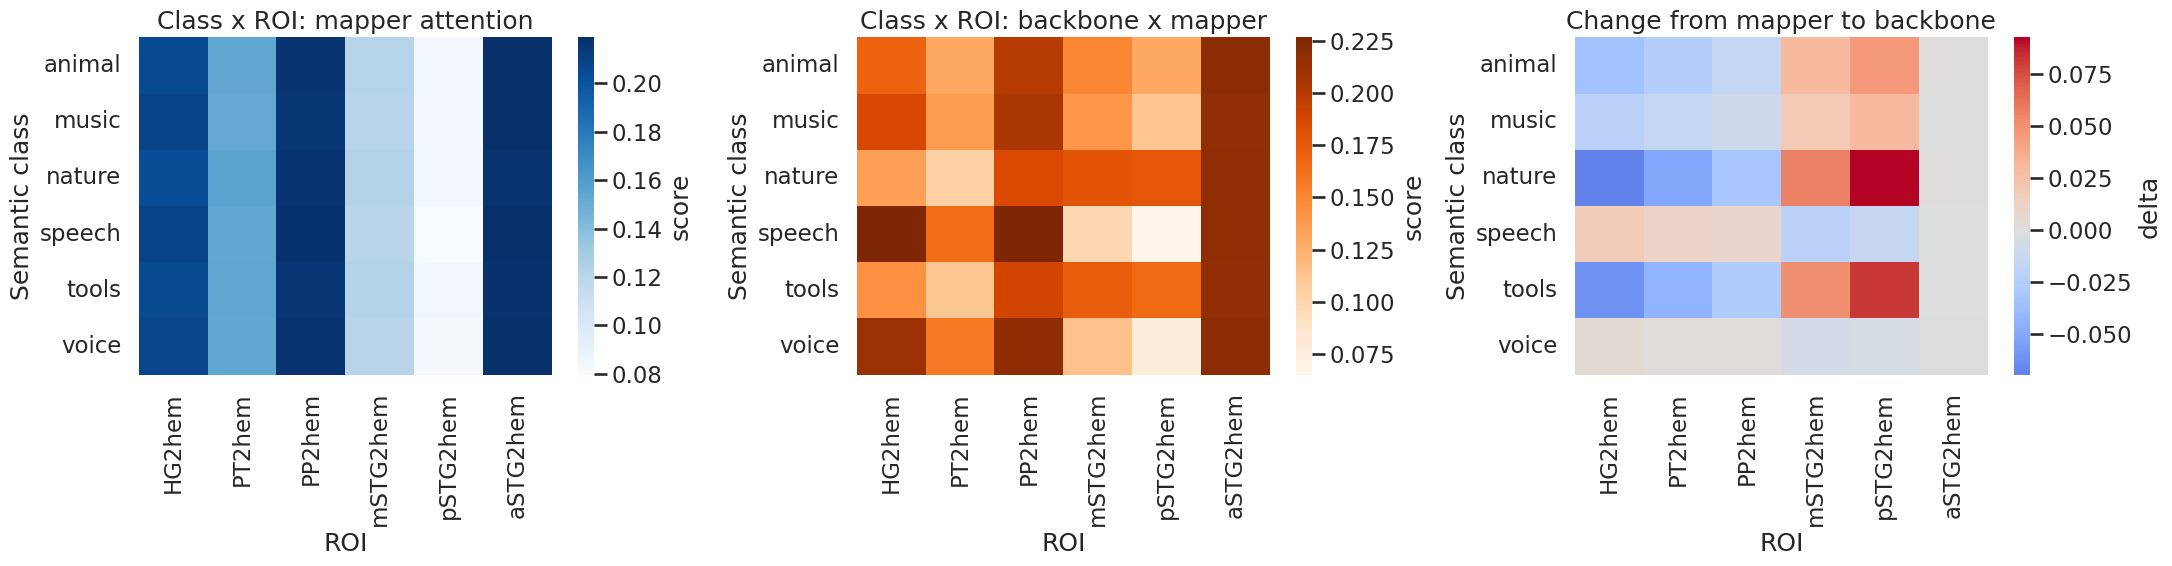

In [23]:
mapper_heat = results['class_mapper_roi'].set_index('semantic_class')[ROI_LIST]
backbone_heat = results['class_backbone_roi'].set_index('semantic_class')[ROI_LIST]
delta_heat = backbone_heat - mapper_heat

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
sns.heatmap(mapper_heat, cmap='Blues', ax=axes[0], cbar_kws={'label': 'score'})
axes[0].set_title('Class x ROI: mapper attention')
axes[0].set_xlabel('ROI')
axes[0].set_ylabel('Semantic class')

sns.heatmap(backbone_heat, cmap='Oranges', ax=axes[1], cbar_kws={'label': 'score'})
axes[1].set_title('Class x ROI: backbone x mapper')
axes[1].set_xlabel('ROI')
axes[1].set_ylabel('Semantic class')

sns.heatmap(delta_heat, cmap='coolwarm', center=0.0, ax=axes[2], cbar_kws={'label': 'delta'})
axes[2].set_title('Change from mapper to backbone')
axes[2].set_xlabel('ROI')
axes[2].set_ylabel('Semantic class')
plt.tight_layout()
plt.show()

In [24]:
from pathlib import Path

EXPORT_DIR = Path('./attention_analysis_outputs_semantic')
EXPORT_DIR.mkdir(exist_ok=True)

results['class_backbone_roi'].to_csv(EXPORT_DIR / 'class_backbone_roi.csv', index=False)
results['class_mapper_roi'].to_csv(EXPORT_DIR / 'class_mapper_roi.csv', index=False)

print('Salvati in:', EXPORT_DIR.resolve())

Salvati in: /home/matteoc/brainSounds/maas_model/attention_analysis_outputs_semantic


,ROI,mapper,backbone_x_mapper,delta
5,aSTG2hem,0.218579,0.219646,0.001067
2,PP2hem,0.216633,0.200791,-0.015843
0,HG2hem,0.205345,0.170515,-0.034830
3,mSTG2hem,0.121887,0.150702,0.028816
1,PT2hem,0.154237,0.129424,-0.024813
4,pSTG2hem,0.083319,0.128922,0.045604


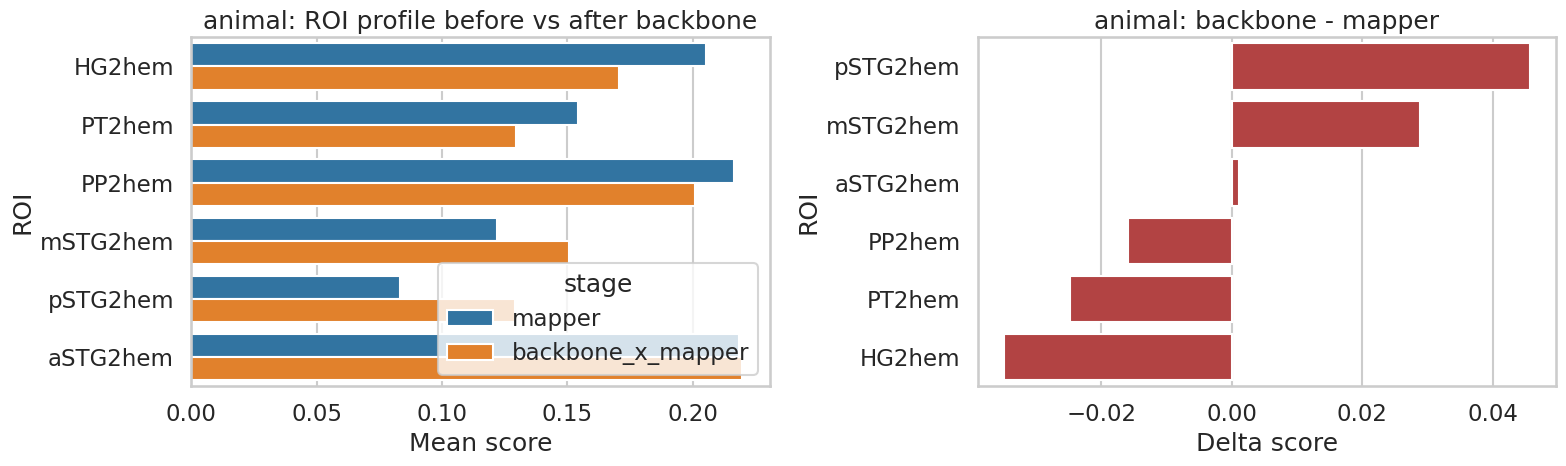

In [25]:
focus_mapper = results['class_mapper_roi'].query('semantic_class == @FOCUS_CLASS')
focus_backbone = results['class_backbone_roi'].query('semantic_class == @FOCUS_CLASS')

if len(focus_mapper) == 0:
    raise ValueError(f'Classe {FOCUS_CLASS} non trovata.')

focus_compare = pd.DataFrame({
    'ROI': ROI_LIST,
    'mapper': focus_mapper[ROI_LIST].iloc[0].values,
    'backbone_x_mapper': focus_backbone[ROI_LIST].iloc[0].values,
})
focus_compare['delta'] = focus_compare['backbone_x_mapper'] - focus_compare['mapper']
display(focus_compare.sort_values('backbone_x_mapper', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=focus_compare.melt(id_vars='ROI', value_vars=['mapper', 'backbone_x_mapper'], var_name='stage', value_name='score'), x='score', y='ROI', hue='stage', ax=axes[0])
axes[0].set_title(f'{FOCUS_CLASS}: ROI profile before vs after backbone')
axes[0].set_xlabel('Mean score')
axes[0].set_ylabel('ROI')

sns.barplot(data=focus_compare.sort_values('delta', ascending=False), x='delta', y='ROI', color='#c53030', ax=axes[1])
axes[1].set_title(f'{FOCUS_CLASS}: backbone - mapper')
axes[1].set_xlabel('Delta score')
axes[1].set_ylabel('ROI')
plt.tight_layout()
plt.show()

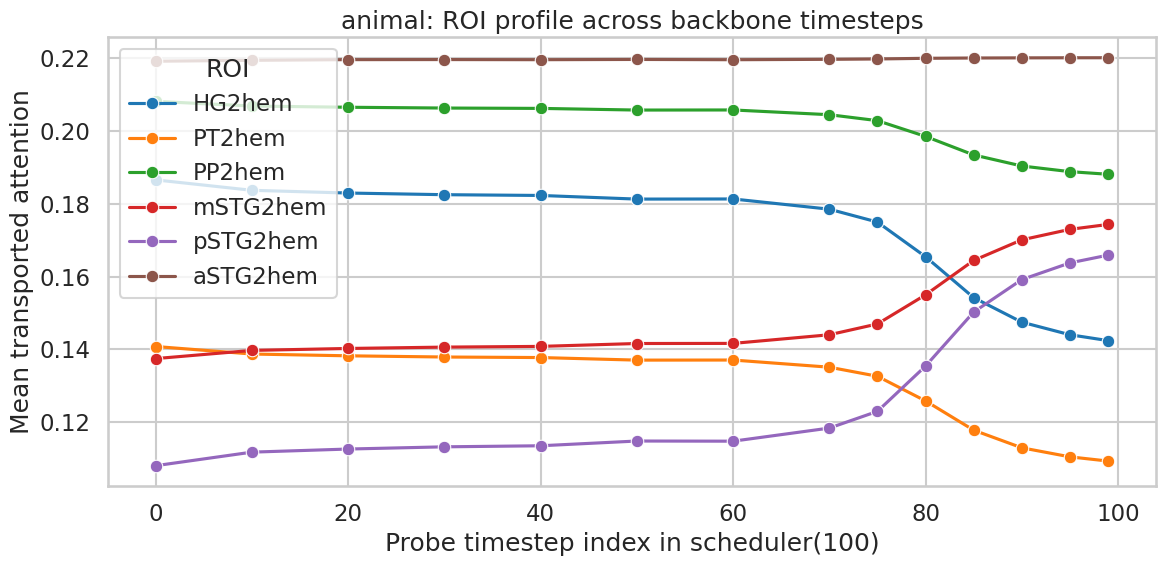

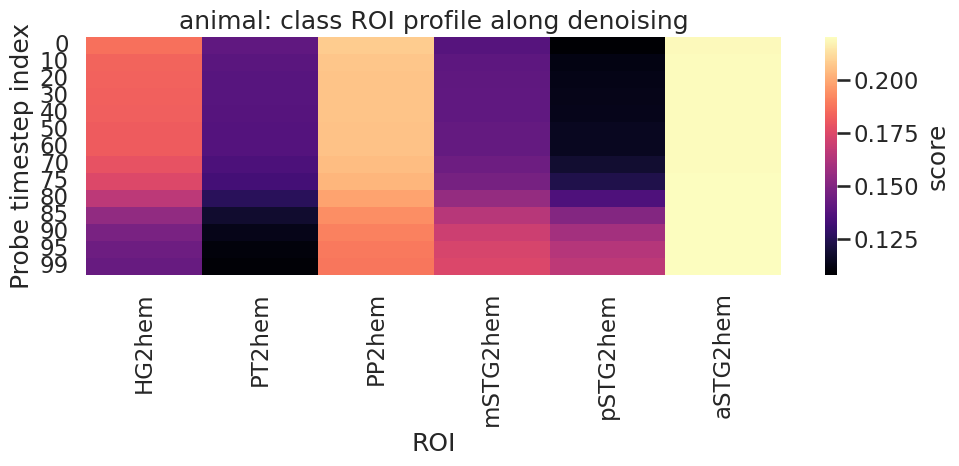

In [26]:
focus_time = results['class_backbone_timestep_roi'].query('semantic_class == @FOCUS_CLASS').copy()
focus_time_long = to_long_roi(focus_time, ['semantic_class', 'timestep_index', 'timestep_value'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=focus_time_long, x='timestep_index', y='score', hue='ROI', marker='o')
plt.title(f'{FOCUS_CLASS}: ROI profile across backbone timesteps')
plt.xlabel('Probe timestep index in scheduler(100)')
plt.ylabel('Mean transported attention')
plt.tight_layout()
plt.show()

pivot_focus_time = focus_time.set_index('timestep_index')[ROI_LIST]
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_focus_time, cmap='magma', cbar_kws={'label': 'score'})
plt.title(f'{FOCUS_CLASS}: class ROI profile along denoising')
plt.xlabel('ROI')
plt.ylabel('Probe timestep index')
plt.tight_layout()
plt.show()

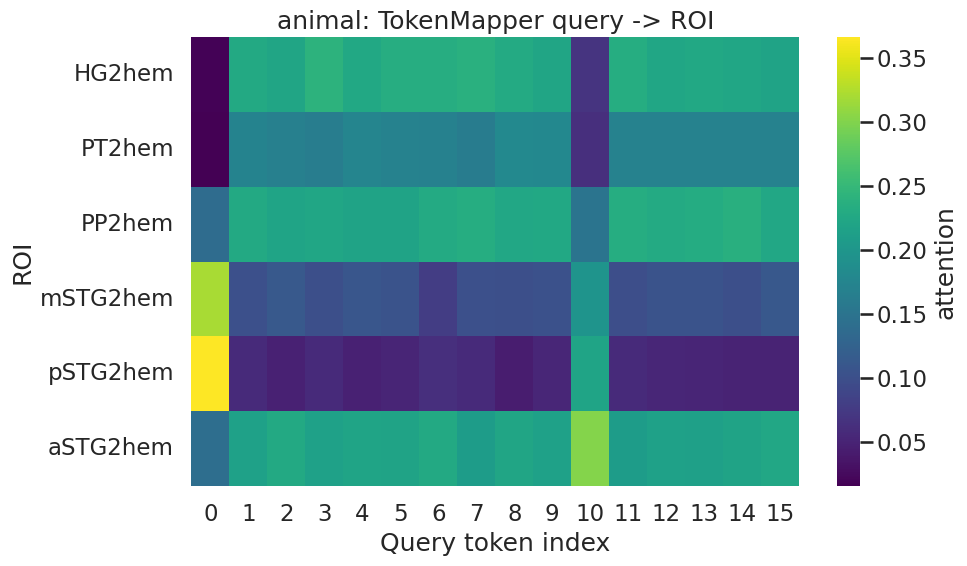

In [27]:
focus_query = results['class_mapper_query_roi'].query('semantic_class == @FOCUS_CLASS').copy()
focus_query_heat = focus_query.set_index('query_idx')[ROI_LIST]

plt.figure(figsize=(10, 6))
sns.heatmap(focus_query_heat.T, cmap='viridis', cbar_kws={'label': 'attention'})
plt.title(f'{FOCUS_CLASS}: TokenMapper query -> ROI')
plt.xlabel('Query token index')
plt.ylabel('ROI')
plt.tight_layout()
plt.show()

## Come leggere i risultati

- Il notebook lavora sui **72 item test unici**, quindi ogni suono contribuisce una sola volta all'analisi di classe.
- `class_mapper_roi` dice quali ROI sono privilegiate dal mapper per ogni classe semantica.
- `class_backbone_roi` dice quali ROI restano importanti dopo aver composto l'attenzione del backbone con quella del mapper.
- `delta = backbone - mapper` mostra dove il backbone enfatizza o de-enfatizza una ROI rispetto all'attenzione iniziale.
- `class_backbone_timestep_roi` serve per vedere se il profilo ROI cambia lungo il denoising.

### Claim prudente ma utile

Per una classe come `speech`, puoi dire qualcosa del tipo:

- "Nel mapper, `speech` mostra una preferenza iniziale per queste ROI..."
- "Nel backbone, questa preferenza si concentra / si redistribuisce verso queste ROI..."
- "Quindi la firma neurale iniziale della classe viene mantenuta oppure trasformata durante la generazione."

### Limite importante

Attenzione alta non significa causalita'. Se vuoi un risultato piu' convincente sul cervello, il passo naturale dopo questo notebook e' un'analisi di **ROI ablation per classe semantica**.

# Single Trial

In [ ]:
# ── Carica etichette testuali dal CSV ─────────────────────────────────────────
# Struttura CSV: oggetto;suono;filename.wav  (senza header)
# Match: sound_name 'stimXX_catXX_CLASS_exempN' → CSV riga con class=CLASS e exemp_rank=N

LABELS_CSV_PATH = '/home/matteoc/brainSounds/maas_data/Labels_288Sounds_ObjectSoundDescription.csv'

labels_df = pd.read_csv(
    LABELS_CSV_PATH,
    sep=';',
    header=None,
    names=['object', 'sound', 'wav_file'],
)

# Estrai classe e numero progressivo dal wav_file (es. 's2_animal_3.wav' → class='animal', num=3)
labels_df['wav_stem'] = labels_df['wav_file'].str.replace(r'\.wav$', '', regex=True)
extracted = labels_df['wav_stem'].str.extract(r's2_([a-zA-Z]+)_(\d+)')
labels_df['class'] = extracted[0]
labels_df['wav_num'] = extracted[1].astype(int)

# Ordina per classe + numero → assegna exemp_rank (1..48 per classe)
# Questo corrisponde all'indice exemp nel sound_name del dataset
labels_df = labels_df.sort_values(['class', 'wav_num']).reset_index(drop=True)
labels_df['exemp_rank'] = labels_df.groupby('class').cumcount() + 1

# Chiave di lookup: 'animal_3', 'music_7', ecc.
labels_df['class_exemp_key'] = labels_df['class'] + '_' + labels_df['exemp_rank'].astype(str)
labels_df['label'] = labels_df['object'] + ' / ' + labels_df['sound']
class_exemp_to_label = dict(zip(labels_df['class_exemp_key'], labels_df['label']))

def sound_name_to_label(sound_name: str) -> str:
    """Converte 'stim05_cat01_animal_exemp03' → 'dog / bark'."""
    import re
    m = re.match(r'stim\d+_cat\d+_([a-zA-Z]+)_exemp(\d+)', str(sound_name))
    if m:
        key = f'{m.group(1)}_{int(m.group(2))}'
        return class_exemp_to_label.get(key, sound_name)
    return str(sound_name)

print(f'Labels caricate: {len(labels_df)} suoni')
print('Verifica matching:')
for test in ['stim05_cat01_animal_exemp03', 'stim12_cat02_music_exemp07', 'stim48_cat03_nature_exemp12']:
    print(f'  {test} → {sound_name_to_label(test)}')


Labels caricate: 288 suoni
Verifica matching:
  stim05_cat01_animal_exemp03 → dog / bark
  stim12_cat02_music_exemp07 → drum / music
  stim48_cat03_nature_exemp12 → wind / blow


In [ ]:
# ── Preparazione dei DataFrame per-trial ──────────────────────────────────────

trial_mapper = results['mapper_roi_df'].copy()
trial_backbone = results['backbone_roi_df'].copy()

# Merge mapper + backbone per avere delta
trial_merged = trial_mapper[['sound_idx', 'sound_name', 'semantic_class'] + ROI_LIST].merge(
    trial_backbone[['sound_idx'] + ROI_LIST],
    on='sound_idx',
    suffixes=('_mapper', '_backbone')
)

# Ordina per classe semantica poi sound_idx
class_order = sorted(trial_merged['semantic_class'].unique())
trial_merged['semantic_class'] = pd.Categorical(
    trial_merged['semantic_class'], categories=class_order, ordered=True
)
trial_merged = trial_merged.sort_values(['semantic_class', 'sound_idx']).reset_index(drop=True)

# Matrici per le heatmap
mapper_mat   = trial_merged[[f'{r}_mapper'   for r in ROI_LIST]].values  # (72, n_rois)
backbone_mat = trial_merged[[f'{r}_backbone' for r in ROI_LIST]].values
delta_mat    = backbone_mat - mapper_mat

# Etichette asse Y: usa sound_name_to_label() dal CSV
y_labels = [
    sound_name_to_label(row['sound_name'])
    for _, row in trial_merged.iterrows()
]

# Linee di separazione tra classi semantiche
class_boundaries = []
class_centers = []
prev_class = None
count = 0
for _, row in trial_merged.iterrows():
    if row['semantic_class'] != prev_class:
        if prev_class is not None:
            class_boundaries.append(count)
        class_centers.append((count, row['semantic_class']))
        prev_class = row['semantic_class']
    count += 1

print(f'Totale trial: {len(trial_merged)}')
print('Distribuzione per classe:')
print(trial_merged['semantic_class'].value_counts().sort_index())
print('\nEsempio y_labels (primi 5):', y_labels[:5])


Totale trial: 72
Distribuzione per classe:
semantic_class
animal    12
music     12
nature    12
speech    12
tools     12
voice     12
Name: count, dtype: int64

Esempio y_labels (primi 5): ['bird / tweet', 'chicken / crow', 'cat / meow', 'duck / quack', 'insect / buzz']


In [ ]:
# ── Helper per annotare le classi sull'asse Y ─────────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba

CLASS_COLORS = {
    cls: color for cls, color in zip(
        class_order,
        sns.color_palette('tab10', len(class_order))
    )
}

def add_class_annotations(ax, class_centers, class_boundaries, n_trials):
    """Aggiunge linee divisorie e barre colorate per classe."""
    for boundary in class_boundaries:
        ax.axhline(y=boundary, color='white', linewidth=2.0, linestyle='--')
    # Barra colorata a sinistra
    for i, (start, cls) in enumerate(class_centers):
        end = class_centers[i + 1][0] if i + 1 < len(class_centers) else n_trials
        mid = (start + end) / 2
        ax.annotate(
            cls,
            xy=(-0.5, mid),
            xycoords=('data', 'data'),
            xytext=(-18, 0),
            textcoords='offset points',
            fontsize=8,
            va='center',
            ha='right',
            color=CLASS_COLORS[cls],
            fontweight='bold',
            annotation_clip=False,
        )
    return ax


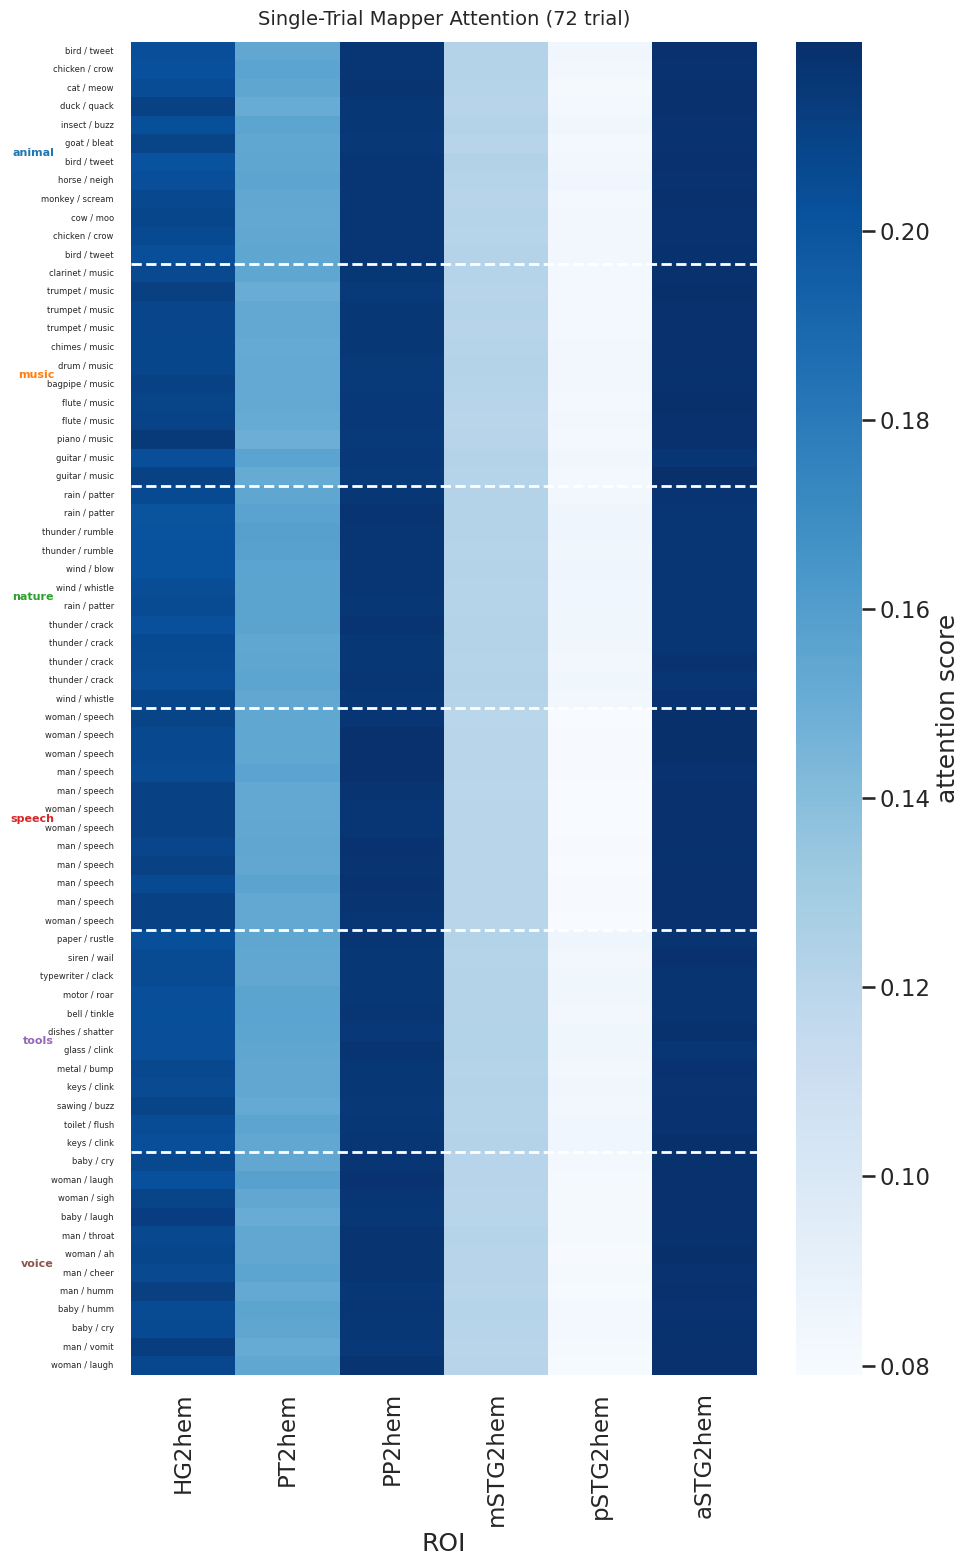

In [ ]:
# ── Plot 1: Mapper attention per trial ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 16))
mapper_df_plot = pd.DataFrame(mapper_mat, columns=ROI_LIST)
sns.heatmap(
    mapper_df_plot,
    cmap='Blues',
    ax=ax,
    yticklabels=y_labels,
    cbar_kws={'label': 'attention score'},
    linewidths=0.0,
)
add_class_annotations(ax, class_centers, class_boundaries, len(trial_merged))
ax.set_title('Single-Trial Mapper Attention (72 trial)', fontsize=14, pad=12)
ax.set_xlabel('ROI')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.show()


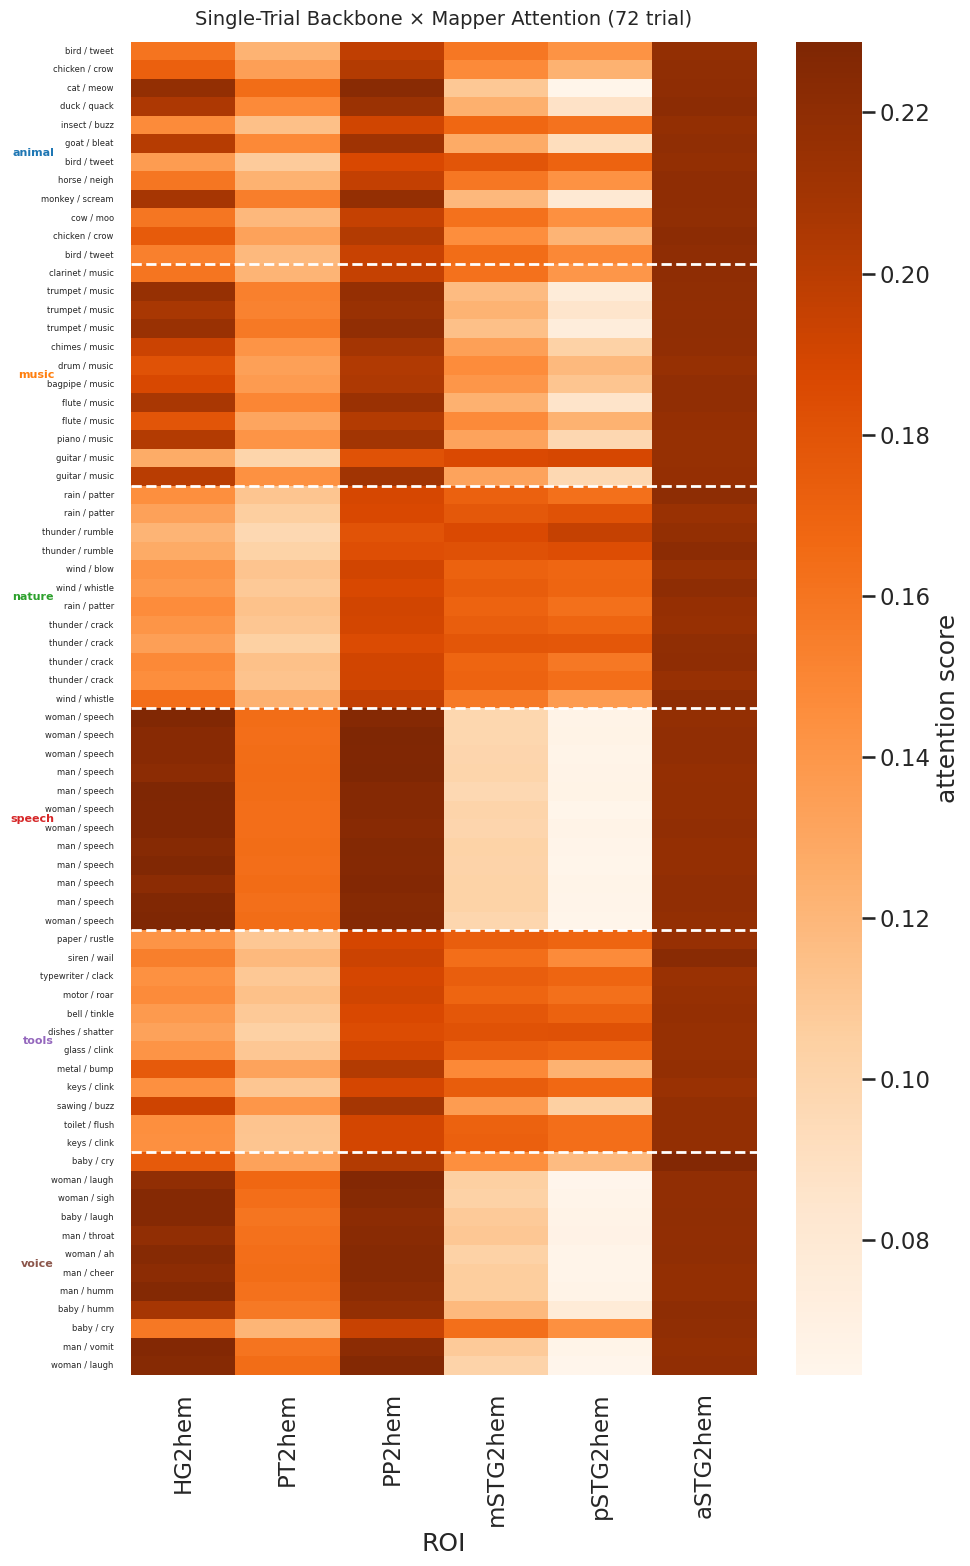

In [ ]:
# ── Plot 2: Backbone x Mapper per trial ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 16))
backbone_df_plot = pd.DataFrame(backbone_mat, columns=ROI_LIST)
sns.heatmap(
    backbone_df_plot,
    cmap='Oranges',
    ax=ax,
    yticklabels=y_labels,
    cbar_kws={'label': 'attention score'},
    linewidths=0.0,
)
add_class_annotations(ax, class_centers, class_boundaries, len(trial_merged))
ax.set_title('Single-Trial Backbone × Mapper Attention (72 trial)', fontsize=14, pad=12)
ax.set_xlabel('ROI')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.show()


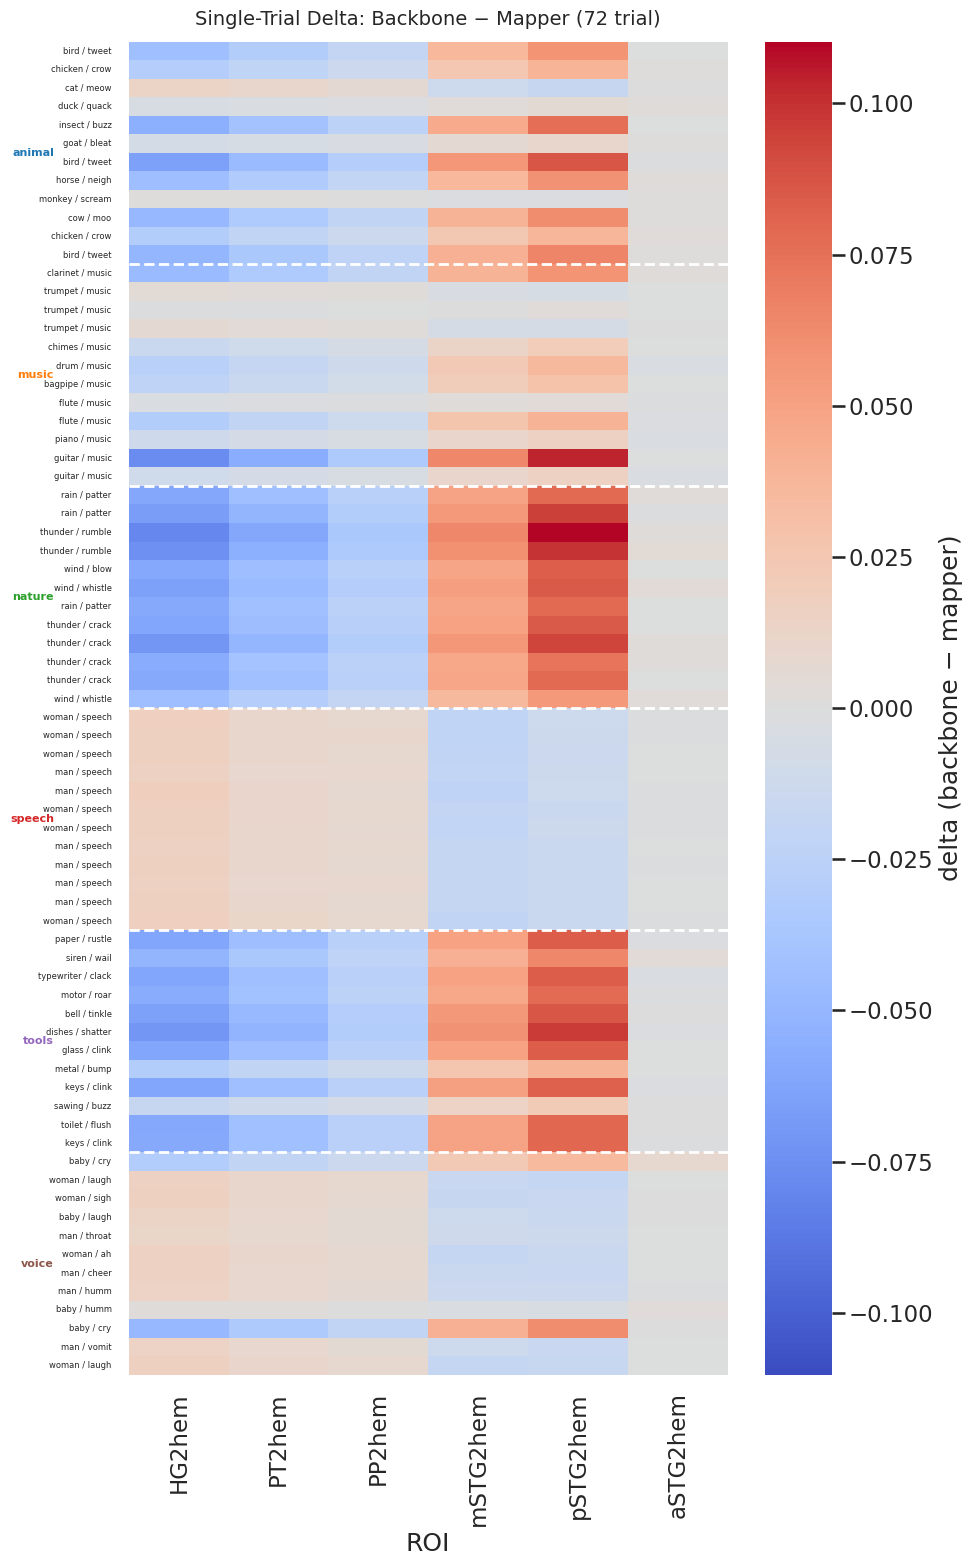

In [ ]:
# ── Plot 3: Delta (Backbone - Mapper) per trial ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 16))
delta_df_plot = pd.DataFrame(delta_mat, columns=ROI_LIST)
vmax = np.abs(delta_mat).max()
sns.heatmap(
    delta_df_plot,
    cmap='coolwarm',
    center=0.0,
    vmin=-vmax,
    vmax=vmax,
    ax=ax,
    yticklabels=y_labels,
    cbar_kws={'label': 'delta (backbone − mapper)'},
    linewidths=0.0,
)
add_class_annotations(ax, class_centers, class_boundaries, len(trial_merged))
ax.set_title('Single-Trial Delta: Backbone − Mapper (72 trial)', fontsize=14, pad=12)
ax.set_xlabel('ROI')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.show()


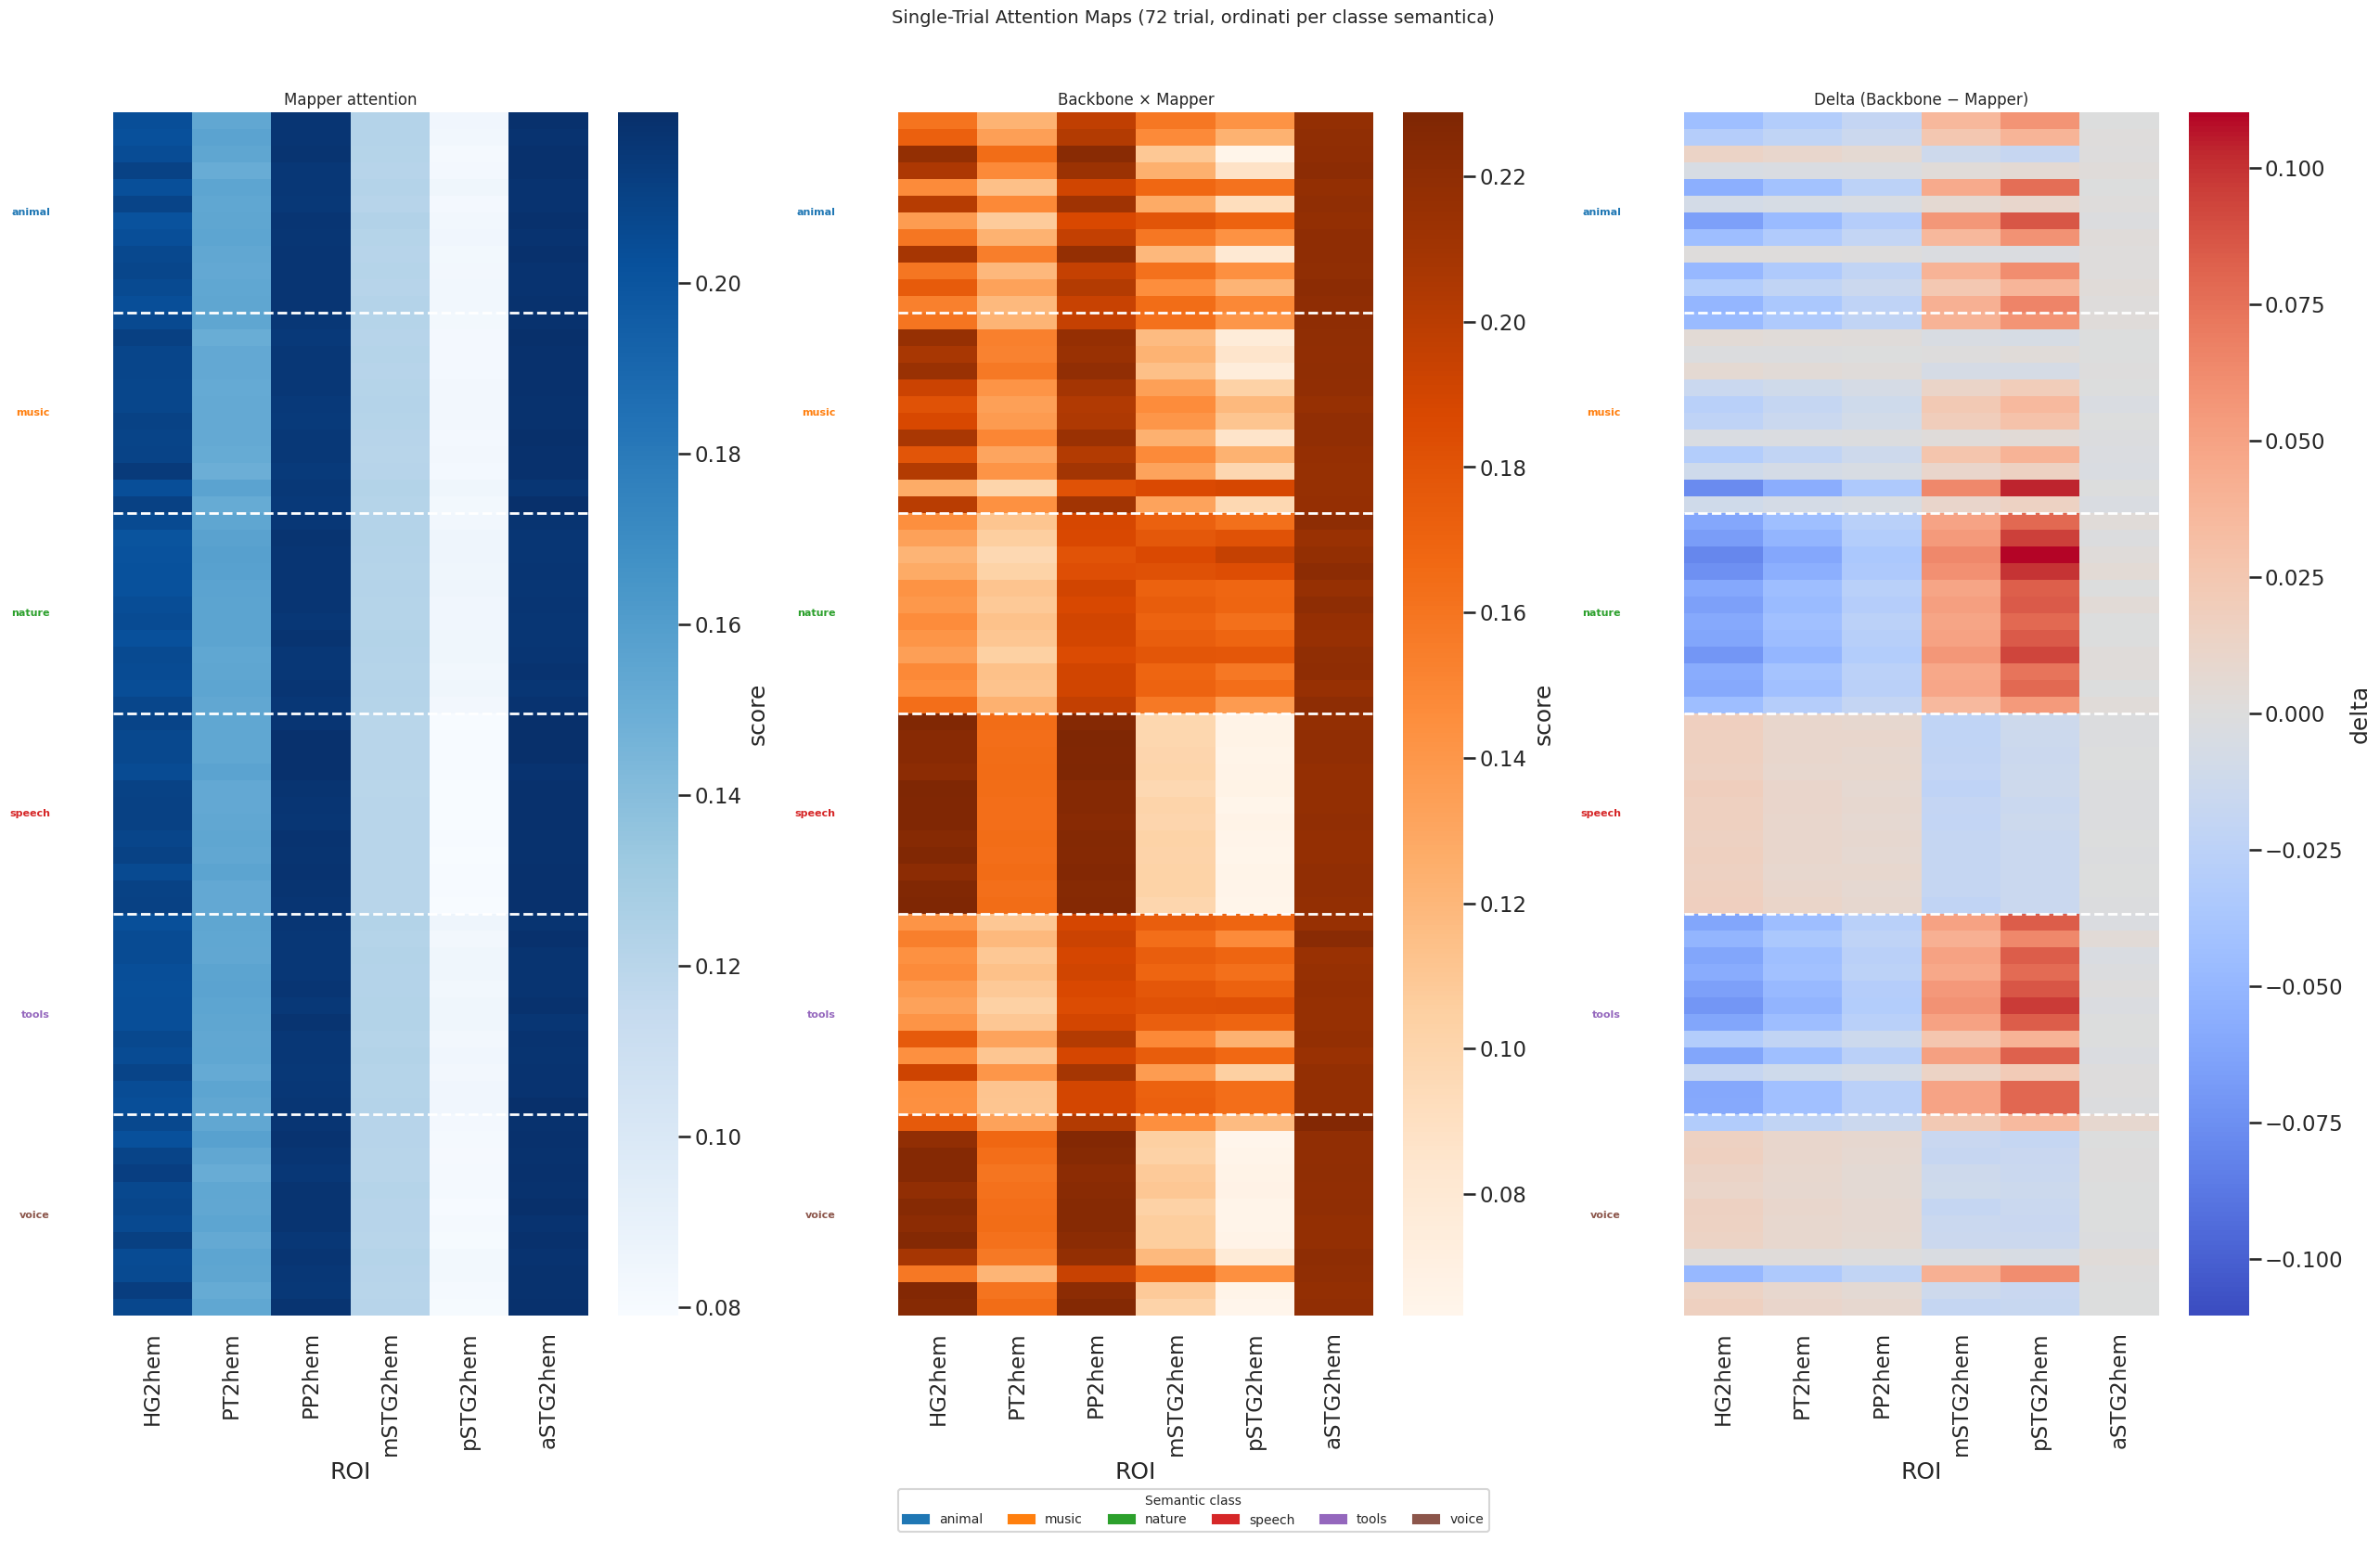

In [ ]:
# ── Plot 4: Vista combinata (3 pannelli) affiancati ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(26, 16), sharey=True)

vmax_delta = np.abs(delta_mat).max()

sns.heatmap(pd.DataFrame(mapper_mat, columns=ROI_LIST), cmap='Blues', ax=axes[0],
            yticklabels=y_labels, cbar_kws={'label': 'score'}, linewidths=0.0)
axes[0].set_title('Mapper attention', fontsize=12)
axes[0].set_xlabel('ROI')
axes[0].tick_params(axis='y', labelsize=5)
add_class_annotations(axes[0], class_centers, class_boundaries, len(trial_merged))

sns.heatmap(pd.DataFrame(backbone_mat, columns=ROI_LIST), cmap='Oranges', ax=axes[1],
            yticklabels=False, cbar_kws={'label': 'score'}, linewidths=0.0)
axes[1].set_title('Backbone × Mapper', fontsize=12)
axes[1].set_xlabel('ROI')
add_class_annotations(axes[1], class_centers, class_boundaries, len(trial_merged))

sns.heatmap(pd.DataFrame(delta_mat, columns=ROI_LIST), cmap='coolwarm', center=0.0,
            vmin=-vmax_delta, vmax=vmax_delta, ax=axes[2],
            yticklabels=False, cbar_kws={'label': 'delta'}, linewidths=0.0)
axes[2].set_title('Delta (Backbone − Mapper)', fontsize=12)
axes[2].set_xlabel('ROI')
add_class_annotations(axes[2], class_centers, class_boundaries, len(trial_merged))

# Legenda classi
patches = [mpatches.Patch(color=CLASS_COLORS[cls], label=cls) for cls in class_order]
fig.legend(handles=patches, loc='lower center', ncol=len(class_order),
           fontsize=10, title='Semantic class', title_fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Single-Trial Attention Maps (72 trial, ordinati per classe semantica)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/seaborn/ax

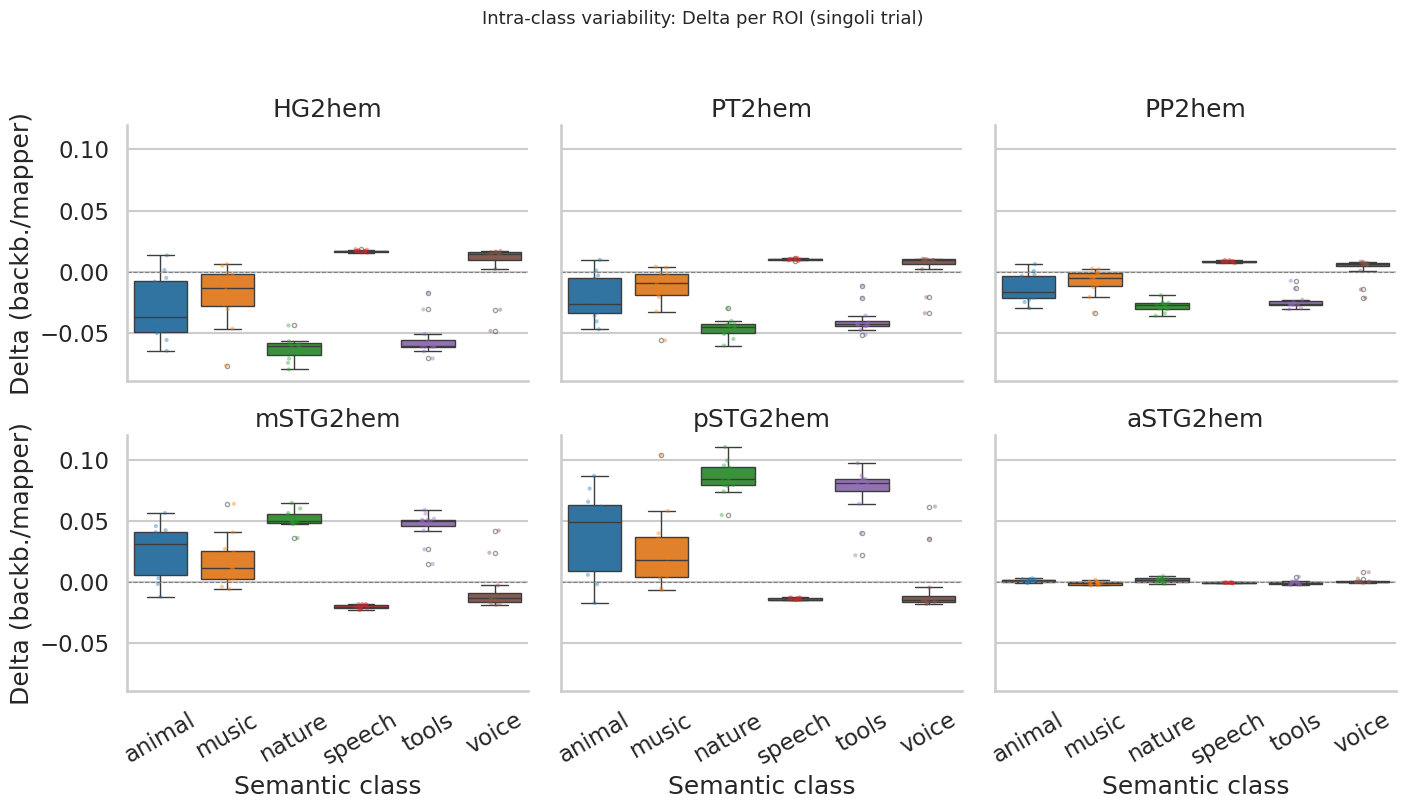

In [ ]:
# ── Plot 5: Variabilità intra-classe — boxplot per ROI e classe ───────────────
# Mostra la distribuzione dei singoli trial per ogni ROI, separata per classe

# Usiamo il delta per vedere dove il backbone è più variabile
delta_long = trial_merged[['sound_idx', 'semantic_class']].copy()
for r in ROI_LIST:
    delta_long[r] = trial_merged[f'{r}_backbone'].values - trial_merged[f'{r}_mapper'].values

delta_long_melt = delta_long.melt(
    id_vars=['sound_idx', 'semantic_class'],
    value_vars=ROI_LIST,
    var_name='ROI',
    value_name='delta'
)

g = sns.FacetGrid(
    delta_long_melt,
    col='ROI',
    col_wrap=3,
    height=4,
    aspect=1.2,
    sharey=True,
)
g.map_dataframe(
    sns.boxplot,
    x='semantic_class',
    y='delta',
    order=class_order,
    palette='tab10',
    flierprops=dict(marker='o', markersize=3, alpha=0.5),
)
g.map_dataframe(
    sns.stripplot,
    x='semantic_class',
    y='delta',
    order=class_order,
    palette='tab10',
    size=3,
    alpha=0.4,
    jitter=True,
)
g.set_axis_labels('Semantic class', 'Delta (backb./mapper)')
g.set_titles(col_template='{col_name}')
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.tick_params(axis='x', rotation=30)
g.figure.suptitle('Intra-class variability: Delta per ROI (singoli trial)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## Interpr Single Trial

In [ ]:
# Identifica gli indici riga dei due trial "bambino che piange"
# (usa sound_name_to_label per trovare le righe giuste)
outlier_names = [
    sn for sn in trial_merged['sound_name']
    if 'cry' in sound_name_to_label(sn).lower()
    and 'baby' in sound_name_to_label(sn).lower()
    or 'cat' in sound_name_to_label(sn).lower()
    and 'meow' in sound_name_to_label(sn).lower()
]
outlier_indices = trial_merged[
    trial_merged['sound_name'].isin(outlier_names)
].index.tolist()

print('Outlier trovati:')
for idx in outlier_indices:
    row = trial_merged.iloc[idx]
    print(f'  row {idx}: {sound_name_to_label(row["sound_name"])} ({row["semantic_class"]})')

Outlier trovati:
  row 2: cat / meow (animal)
  row 60: baby / cry (voice)
  row 69: baby / cry (voice)


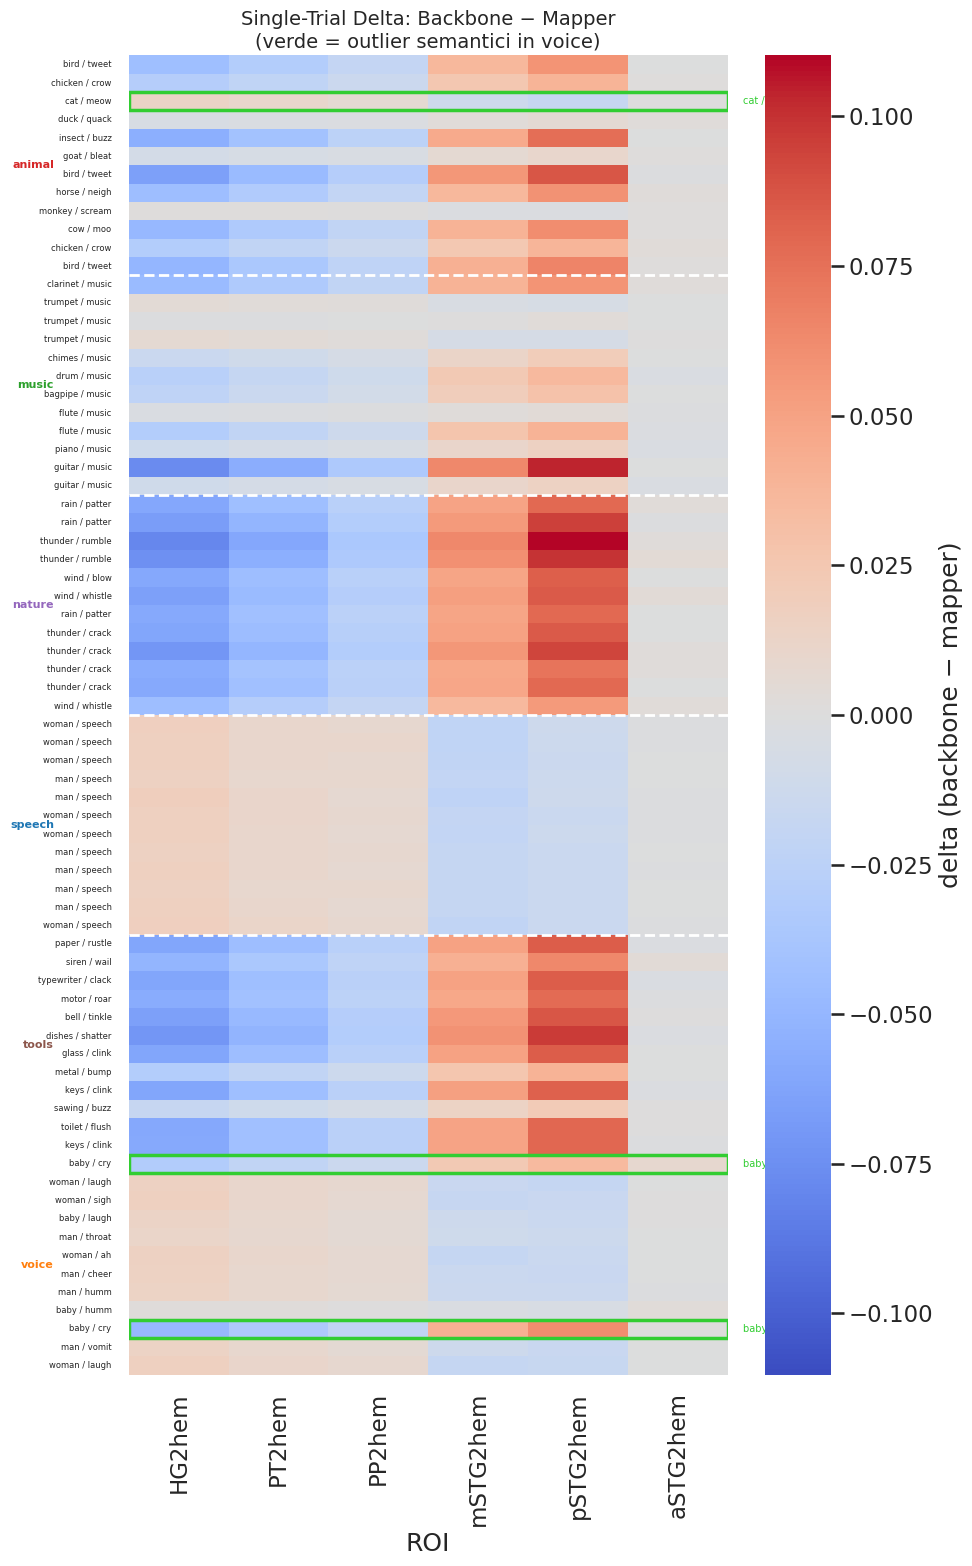

In [ ]:
# Heatmap delta con bordi evidenziati sugli outlier
fig, ax = plt.subplots(figsize=(10, 16))
vmax = np.abs(delta_mat).max()
sns.heatmap(
    pd.DataFrame(delta_mat, columns=ROI_LIST),
    cmap='coolwarm', center=0.0, vmin=-vmax, vmax=vmax,
    ax=ax, yticklabels=y_labels,
    cbar_kws={'label': 'delta (backbone − mapper)'},
    linewidths=0.0,
)
add_class_annotations(ax, class_centers, class_boundaries, len(trial_merged))

# Rettangolo colorato sulle righe outlier
for idx in outlier_indices:
    ax.add_patch(plt.Rectangle(
        (0, idx), len(ROI_LIST), 1,
        fill=False, edgecolor='limegreen', lw=2.5, zorder=5
    ))
    ax.text(
        len(ROI_LIST) + 0.15, idx + 0.5,
        sound_name_to_label(trial_merged.iloc[idx]['sound_name']),
        va='center', fontsize=7, color='limegreen',
    )

ax.set_title('Single-Trial Delta: Backbone − Mapper\n(verde = outlier semantici in voice)', fontsize=14)
ax.set_xlabel('ROI')
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.show()

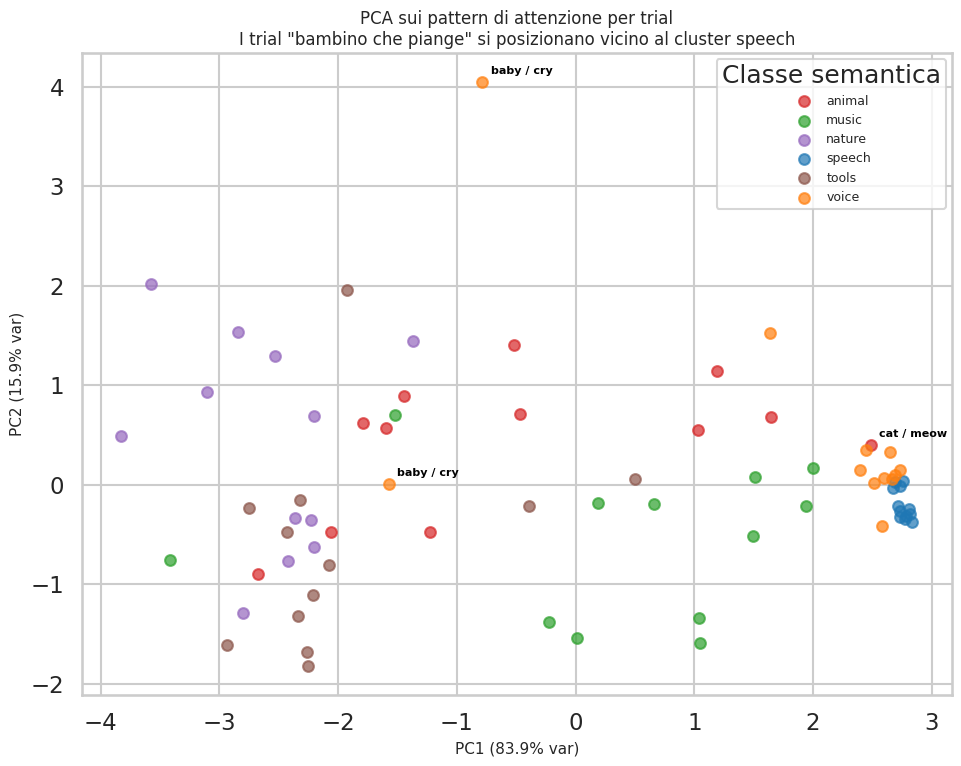

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(delta_mat)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot tutti i trial
for cls in class_order:
    mask = trial_merged['semantic_class'] == cls
    idxs = trial_merged[mask].index.tolist()
    ax.scatter(
        X_2d[idxs, 0], X_2d[idxs, 1],
        color=CLASS_COLORS[cls], s=60, alpha=0.7,
        label=cls, zorder=3,
    )

# Evidenzia gli outlier
for idx in outlier_indices:
    ax.annotate(
        sound_name_to_label(trial_merged.iloc[idx]['sound_name']),
        (X_2d[idx, 0], X_2d[idx, 1]),
        fontsize=8, xytext=(6, 6),
        textcoords='offset points',
        color='black',
        fontweight='bold',
    )

var_exp = pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)', fontsize=11)
ax.set_title(
    'PCA sui pattern di attenzione per trial\n'
    'I trial "bambino che piange" si posizionano vicino al cluster speech',
    fontsize=12
)
ax.legend(title='Classe semantica', fontsize=9)
plt.tight_layout()
plt.show()

# Statistics

In [ ]:
from itertools import product as iproduct
import warnings
from scipy.stats import false_discovery_control  # scipy >= 1.11

ALPHA = 0.05
N_PERM_INTER = 10_00
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# ── Costruisci delta per-trial ──────────────────────────────────────────────
# trial_merged è già disponibile dalla sezione single-trial
delta_trial = trial_merged[['sound_idx', 'semantic_class']].copy()
for r in ROI_LIST:
    delta_trial[r] = trial_merged[f'{r}_backbone'].values - trial_merged[f'{r}_mapper'].values

# ── Test 1: one-sample permutation test (delta vs 0) ────────────────────────
# Per ogni (classe, ROI): permuto i segni dei 12 delta (permutazioni esatte 2^12 = 4096)
def one_sample_perm_test_exact(x: np.ndarray) -> float:
    """P-value esatto tramite enumerazione di tutti i segni possibili."""
    n = len(x)
    observed = np.abs(np.mean(x))
    # Genera tutte le 2^n combinazioni di segni
    signs = np.array(list(iproduct([-1, 1], repeat=n)))  # (2^n, n)
    null_means = np.abs((signs * x).mean(axis=1))         # (2^n,)
    p = (null_means >= observed).mean()
    return float(p)

rows_t1 = []
for cls in class_order:
    sub = delta_trial[delta_trial['semantic_class'] == cls]
    for r in ROI_LIST:
        x = sub[r].values
        p = one_sample_perm_test_exact(x)
        rows_t1.append({
            'semantic_class': cls,
            'ROI': r,
            'mean_delta': float(x.mean()),
            'p_raw': p,
        })

df_t1 = pd.DataFrame(rows_t1)

# FDR Benjamini-Hochberg sulle 36 p-value
try:
    df_t1['p_fdr'] = false_discovery_control(df_t1['p_raw'].values, method='bh')
except Exception:
    # fallback manuale se scipy < 1.11
    from statsmodels.stats.multitest import multipletests
    _, p_fdr, _, _ = multipletests(df_t1['p_raw'].values, method='fdr_bh')
    df_t1['p_fdr'] = p_fdr

df_t1['significant'] = df_t1['p_fdr'] < ALPHA

print(f'Test 1 — Celle significative (FDR < {ALPHA}): {df_t1["significant"].sum()} / 36')
display(df_t1[df_t1['significant']].sort_values('p_fdr').to_string())


Test 1 — Celle significative (FDR < 0.05): 29 / 36


'   semantic_class       ROI  mean_delta     p_raw     p_fdr  significant\n12         nature    HG2hem   -0.063170  0.000488  0.001099         True\n13         nature    PT2hem   -0.046039  0.000488  0.001099         True\n14         nature    PP2hem   -0.028189  0.000488  0.001099         True\n15         nature  mSTG2hem    0.051322  0.000488  0.001099         True\n27          tools  mSTG2hem    0.045513  0.000488  0.001099         True\n26          tools    PP2hem   -0.024182  0.000488  0.001099         True\n25          tools    PT2hem   -0.039308  0.000488  0.001099         True\n28          tools  pSTG2hem    0.073402  0.000488  0.001099         True\n24          tools    HG2hem   -0.054795  0.000488  0.001099         True\n23         speech  aSTG2hem   -0.000792  0.000488  0.001099         True\n21         speech  mSTG2hem   -0.020307  0.000488  0.001099         True\n22         speech  pSTG2hem   -0.014106  0.000488  0.001099         True\n20         speech    PP2hem    0.0082

In [ ]:
# ── Test 2: permutation test inter-classe ───────────────────────────────────
# Statistica: mean_delta(classe) - mean_delta(tutte le altre classi)
# H0: le etichette di classe sono intercambiabili

all_classes = np.array(delta_trial['semantic_class'].values)   # (72,)
delta_vals   = delta_trial[ROI_LIST].values                    # (72, n_rois)

rows_t2 = []
for cls_idx, cls in enumerate(class_order):
    mask_cls = (all_classes == cls)      # 12 True, 60 False
    for roi_idx, r in enumerate(ROI_LIST):
        x = delta_vals[:, roi_idx]       # (72,)
        # Statistica osservata
        obs = x[mask_cls].mean() - x[~mask_cls].mean()

        # Null distribution: permuto le etichette di classe
        null = np.empty(N_PERM_INTER)
        for k in range(N_PERM_INTER):
            perm_idx = rng.permutation(72)
            null[k] = x[perm_idx[:12]].mean() - x[perm_idx[12:]].mean()

        # Two-tailed p-value
        p = (np.abs(null) >= np.abs(obs)).mean()
        rows_t2.append({
            'semantic_class': cls,
            'ROI': r,
            'contrast': float(obs),
            'p_raw': float(p),
        })

df_t2 = pd.DataFrame(rows_t2)

try:
    df_t2['p_fdr'] = false_discovery_control(df_t2['p_raw'].values, method='bh')
except Exception:
    from statsmodels.stats.multitest import multipletests
    _, p_fdr, _, _ = multipletests(df_t2['p_raw'].values, method='fdr_bh')
    df_t2['p_fdr'] = p_fdr

df_t2['significant'] = df_t2['p_fdr'] < ALPHA

print(f'Test 2 — Celle significative (FDR < {ALPHA}): {df_t2["significant"].sum()} / 36')
display(df_t2[df_t2['significant']].sort_values('p_fdr').to_string())


Test 2 — Celle significative (FDR < 0.05): 22 / 36


'   semantic_class       ROI  contrast  p_raw     p_fdr  significant\n12         nature    HG2hem -0.046522  0.000  0.000000         True\n13         nature    PT2hem -0.033637  0.000  0.000000         True\n14         nature    PP2hem -0.020974  0.000  0.000000         True\n15         nature  mSTG2hem  0.039119  0.000  0.000000         True\n18         speech    HG2hem  0.049524  0.000  0.000000         True\n16         nature  pSTG2hem  0.060437  0.000  0.000000         True\n20         speech    PP2hem  0.022770  0.000  0.000000         True\n19         speech    PT2hem  0.033696  0.000  0.000000         True\n24          tools    HG2hem -0.036473  0.000  0.000000         True\n25          tools    PT2hem -0.025560  0.000  0.000000         True\n21         speech  mSTG2hem -0.046837  0.000  0.000000         True\n22         speech  pSTG2hem -0.058051  0.000  0.000000         True\n26          tools    PP2hem -0.016166  0.000  0.000000         True\n27          tools  mSTG2hem  0.03

/tmp/ipykernel_1146316/2122496213.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delta_pivot = delta_trial.groupby('semantic_class')[ROI_LIST].mean()


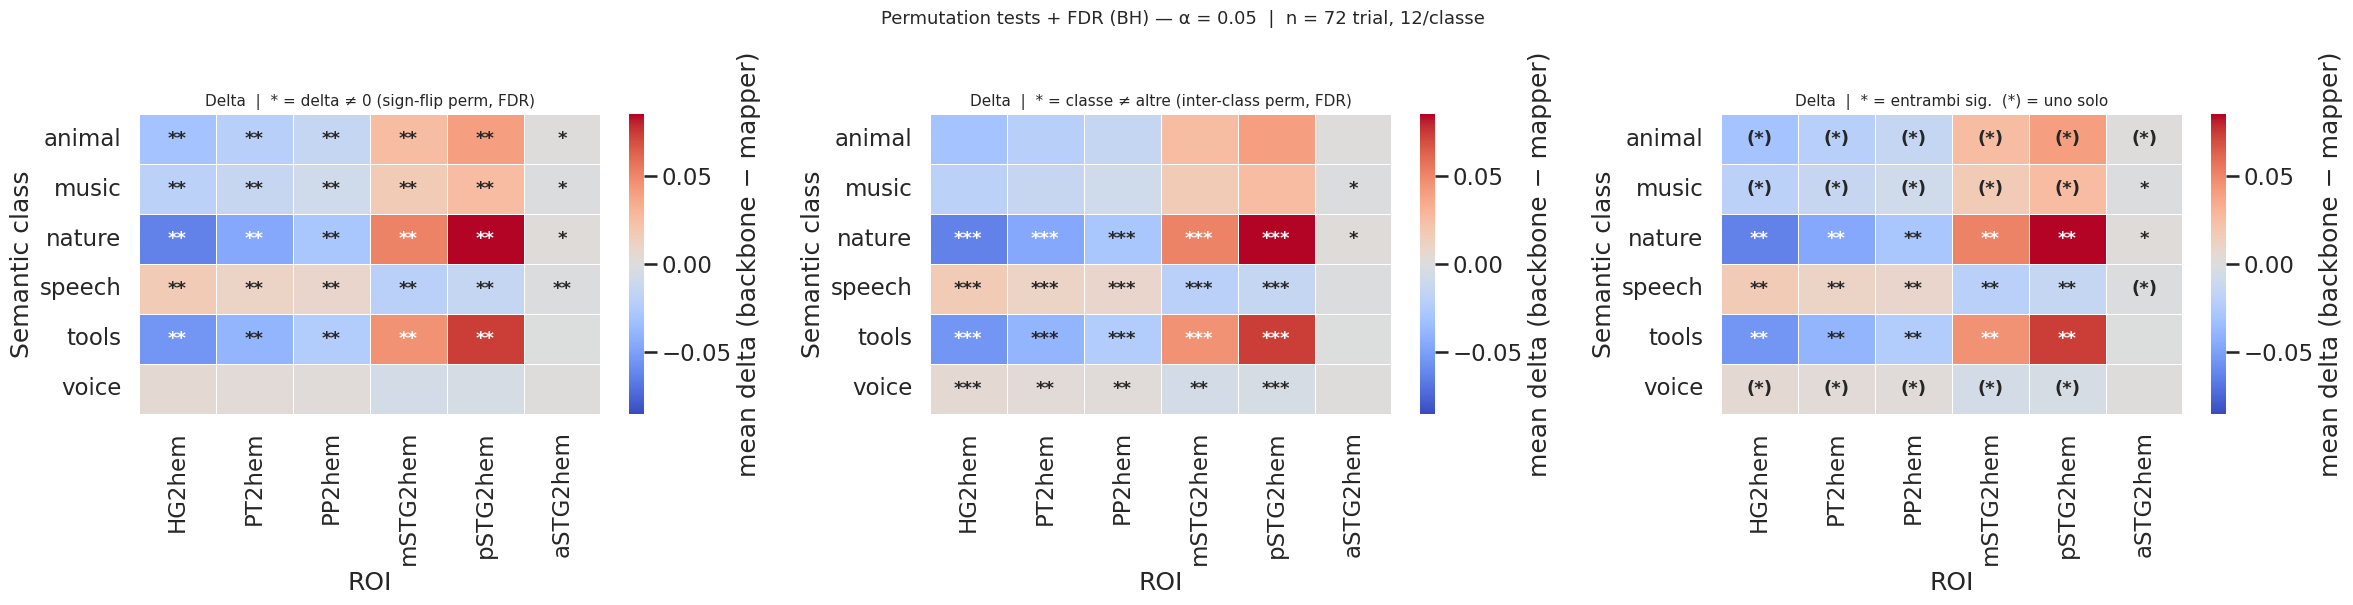

In [ ]:
# ── Heatmap delta con significatività sovrapposta ───────────────────────────
# Convenzione asterischi (post-FDR):
#   *   p_fdr < 0.05
#   **  p_fdr < 0.01
#   *** p_fdr < 0.001

def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

# Pivot per heatmap
delta_pivot = delta_trial.groupby('semantic_class')[ROI_LIST].mean()
delta_pivot = delta_pivot.loc[class_order]   # ordine fisso

# Matrici di asterischi (6×6)
annot_t1 = pd.DataFrame('', index=class_order, columns=ROI_LIST)
annot_t2 = pd.DataFrame('', index=class_order, columns=ROI_LIST)
annot_both = pd.DataFrame('', index=class_order, columns=ROI_LIST)

for _, row in df_t1.iterrows():
    annot_t1.loc[row['semantic_class'], row['ROI']] = sig_label(row['p_fdr'])
for _, row in df_t2.iterrows():
    annot_t2.loc[row['semantic_class'], row['ROI']] = sig_label(row['p_fdr'])

# Combinato: entrambi i test significativi → asterischi pieni; solo uno → asterischi grigi
for cls in class_order:
    for r in ROI_LIST:
        s1 = annot_t1.loc[cls, r]
        s2 = annot_t2.loc[cls, r]
        if s1 and s2:
            annot_both.loc[cls, r] = s1  # entrambi: usa stelle di t1
        elif s1 or s2:
            annot_both.loc[cls, r] = '(*)' # uno solo: marginale

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

for ax, annot, title in zip(
    axes,
    [annot_t1, annot_t2, annot_both],
    [
        'Delta  |  * = delta ≠ 0 (sign-flip perm, FDR)',
        'Delta  |  * = classe ≠ altre (inter-class perm, FDR)',
        'Delta  |  * = entrambi sig.  (*) = uno solo',
    ]
):
    vmax = np.abs(delta_pivot.values).max()
    sns.heatmap(
        delta_pivot,
        cmap='coolwarm',
        center=0.0,
        vmin=-vmax, vmax=vmax,
        annot=annot,
        fmt='',
        annot_kws={'size': 13, 'weight': 'bold'},
        ax=ax,
        cbar_kws={'label': 'mean delta (backbone − mapper)'},
        linewidths=0.4,
        linecolor='white',
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('ROI')
    ax.set_ylabel('Semantic class')

fig.suptitle(
    f'Permutation tests + FDR (BH) — α = {ALPHA}  |  n = 72 trial, 12/classe',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()


In [ ]:
# ── Tabella riassuntiva per claim neuroscientifici ──────────────────────────
summary = df_t1[['semantic_class', 'ROI', 'mean_delta', 'p_fdr']].merge(
    df_t2[['semantic_class', 'ROI', 'contrast', 'p_fdr']],
    on=['semantic_class', 'ROI'],
    suffixes=('_t1', '_t2'),
)
summary['sig_t1'] = summary['p_fdr_t1'] < ALPHA
summary['sig_t2'] = summary['p_fdr_t2'] < ALPHA
summary['claim_strength'] = (
    summary['sig_t1'].astype(int) + summary['sig_t2'].astype(int)
).map({0: '—', 1: 'marginal', 2: 'strong ✓'})

print('=== Celle con almeno un test significativo ===')
display(
    summary[summary['claim_strength'] != '—']
    .sort_values(['claim_strength', 'p_fdr_t1'], ascending=[False, True])
    [['semantic_class', 'ROI', 'mean_delta', 'p_fdr_t1', 'contrast', 'p_fdr_t2', 'claim_strength']]
    .rename(columns={
        'mean_delta': 'Δ (mean)',
        'p_fdr_t1': 'p_FDR (Δ≠0)',
        'contrast': 'Δ vs others',
        'p_fdr_t2': 'p_FDR (inter-class)',
        'claim_strength': 'strength',
    })
    .style.format({
        'Δ (mean)': '{:.4f}',
        'p_FDR (Δ≠0)': '{:.4f}',
        'Δ vs others': '{:.4f}',
        'p_FDR (inter-class)': '{:.4f}',
    })
    .applymap(lambda v: 'background-color: #d4edda' if v == 'strong ✓' else '', subset=['strength'])
)


=== Celle con almeno un test significativo ===


/tmp/ipykernel_1146316/450565429.py:31: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'background-color: #d4edda' if v == 'strong ✓' else '', subset=['strength'])


,semantic_class,ROI,Δ (mean),p_FDR (Δ≠0),Δ vs others,p_FDR (inter-class),strength
12,nature,HG2hem,-0.0632,0.0011,-0.0465,0.0000,strong ✓
13,nature,PT2hem,-0.0460,0.0011,-0.0336,0.0000,strong ✓
14,nature,PP2hem,-0.0282,0.0011,-0.0210,0.0000,strong ✓
15,nature,mSTG2hem,0.0513,0.0011,0.0391,0.0000,strong ✓
16,nature,pSTG2hem,0.0846,0.0011,0.0604,0.0000,strong ✓
18,speech,HG2hem,0.0169,0.0011,0.0495,0.0000,strong ✓
19,speech,PT2hem,0.0101,0.0011,0.0337,0.0000,strong ✓
20,speech,PP2hem,0.0083,0.0011,0.0228,0.0000,strong ✓
21,speech,mSTG2hem,-0.0203,0.0011,-0.0468,0.0000,strong ✓
22,speech,pSTG2hem,-0.0141,0.0011,-0.0581,0.0000,strong ✓


### Come leggere i risultati

| Colonna | Significato |
|---|---|
| `Δ (mean)` | Direzione e magnitudo del cambiamento (backbone − mapper) |
| `p_FDR (Δ≠0)` | Il backbone sposta **sistematicamente** l'attenzione su questa ROI per questa classe? |
| `Δ vs others` | Il delta di questa classe è **diverso** da quello delle altre classi su questa ROI? |
| `p_FDR (inter-class)` | Selettività di classe per questa ROI |
| `strength` | **strong ✓** = entrambi i test sig. → claim neuroscientificamente solido |

**Claim solido** = il backbone (a) sposta l'attenzione in modo non casuale **e** (b) lo fa in modo selettivo per quella classe rispetto alle altre.  
**Marginal** = solo un test supera FDR: da riportare con cautela o usare per ipotesi future.

> **Nota metodologica**: il test 1 usa permutazioni esatte (4096) per sfruttare al massimo il piccolo campione (n=12/classe). Il test 2 usa Monte Carlo (10 000 permutazioni) sull'intero set (n=72).


# Causality

In [ ]:
@torch.no_grad()
def run_roi_ablation(
    model: AudioNeuroAdapter,
    loader: DataLoader,
    sound_meta: pd.DataFrame,
    ablation_mode: str = 'zero',  # 'zero' | 'noise'
):
    """
    Per ogni trial e ogni ROI:
      - forward baseline (brain integro)
      - forward ablated  (brain[:, roi_idx, :] = 0 oppure rumore)
    Restituisce un DataFrame con degradazione per (sound_idx, semantic_class, ROI).

    ablation_mode:
      'zero'  → azzera i voxel della ROI (eliminazione del segnale)
      'noise' → sostituisce con rumore gaussiano N(0,1) (disruption del segnale)
    """
    sound_meta_map = sound_meta.set_index('sound_idx')
    rows = []

    for batch_idx, batch in enumerate(loader):
        brain    = batch['brain_data'].to(device)    # (B, n_rois, n_voxels)
        sound_idx = batch['sound_idx'].cpu().numpy()
        B = brain.shape[0]

        # ── Baseline: forward con brain integro ──────────────────────────────
        tokens_baseline, _ = model.guidance_generator(brain)  # (B, n_tokens, d)
        tokens_baseline = tokens_baseline.detach()             # (B, n_tokens, d)

        # ── Ablation: una ROI alla volta ─────────────────────────────────────
        for roi_idx, roi_name in enumerate(ROI_LIST):
            brain_abl = brain.clone()
            if ablation_mode == 'zero':
                brain_abl[:, roi_idx, :] = 0.0
            elif ablation_mode == 'noise':
                brain_abl[:, roi_idx, :] = torch.randn_like(brain[:, roi_idx, :])
            else:
                raise ValueError(f'ablation_mode sconosciuto: {ablation_mode}')

            tokens_abl, _ = model.guidance_generator(brain_abl)  # (B, n_tokens, d)
            tokens_abl = tokens_abl.detach()

            # Distanza coseno media sui token: 1 - cos_sim
            # cos_sim ha shape (B, n_tokens) → media su tokens → (B,)
            cos_sim = F.cosine_similarity(
                tokens_baseline, tokens_abl, dim=-1
            )  # (B, n_tokens)
            cos_dist = (1.0 - cos_sim).mean(dim=-1)  # (B,)

            # Distanza L2 normalizzata (per token dimension)
            l2_dist = (
                (tokens_baseline - tokens_abl).norm(dim=-1).mean(dim=-1)
                / tokens_baseline.norm(dim=-1).mean(dim=-1).clamp(min=1e-8)
            )  # (B,)

            for i in range(B):
                meta = sound_meta_map.loc[int(sound_idx[i])]
                rows.append({
                    'sound_idx':      int(sound_idx[i]),
                    'sound_name':     meta['sound_name'],
                    'semantic_class': meta['semantic_class'],
                    'ROI':            roi_name,
                    'cos_dist':       float(cos_dist[i].item()),
                    'l2_dist_norm':   float(l2_dist[i].item()),
                })

        if (batch_idx + 1) % 5 == 0:
            print(f'  Ablation batch {batch_idx + 1}/{len(loader)}')

    return pd.DataFrame(rows)


print('Avvio ablation (zero-out)...')
ablation_df = run_roi_ablation(model, loader, sound_meta, ablation_mode='zero')
print(f'Done. Righe: {len(ablation_df)}')
print(ablation_df.head(12).to_string())


Avvio ablation (zero-out)...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Ablation batch 5/18
  Ablation batch 10/18
  Ablation batch 15/18
Done. Righe: 432
    sound_idx                    sound_name semantic_class     ROI  cos_dist  l2_dist_norm
0           0  stim001_cat01_speech_exemp01         speech  HG2hem  0.020922      0.194049
1           1  stim002_cat01_speech_exemp02         speech  HG2hem  0.015370      0.166401
2           2  stim003_cat01_speech_exemp03         speech  HG2hem  0.024117      0.208806
3          10  stim011_cat01_speech_exemp11         speech  HG2hem  0.060688      0.330999
4           0  stim001_cat01_speech_exemp01         speech  PT2hem  0.022497      0.201574
5           1  stim002_cat01_speech_exemp02         speech  PT2hem  0.018786      0.184292
6           2  stim003_cat01_speech_exemp03         speech  PT2hem  0.017552      0.178464
7          10  stim011_cat01_speech_exemp11         speech  PT2hem  0.026979      0.221226
8           0  stim001_cat01_speech_exemp01         speech  PP2hem  0.027087      0.228634
9    

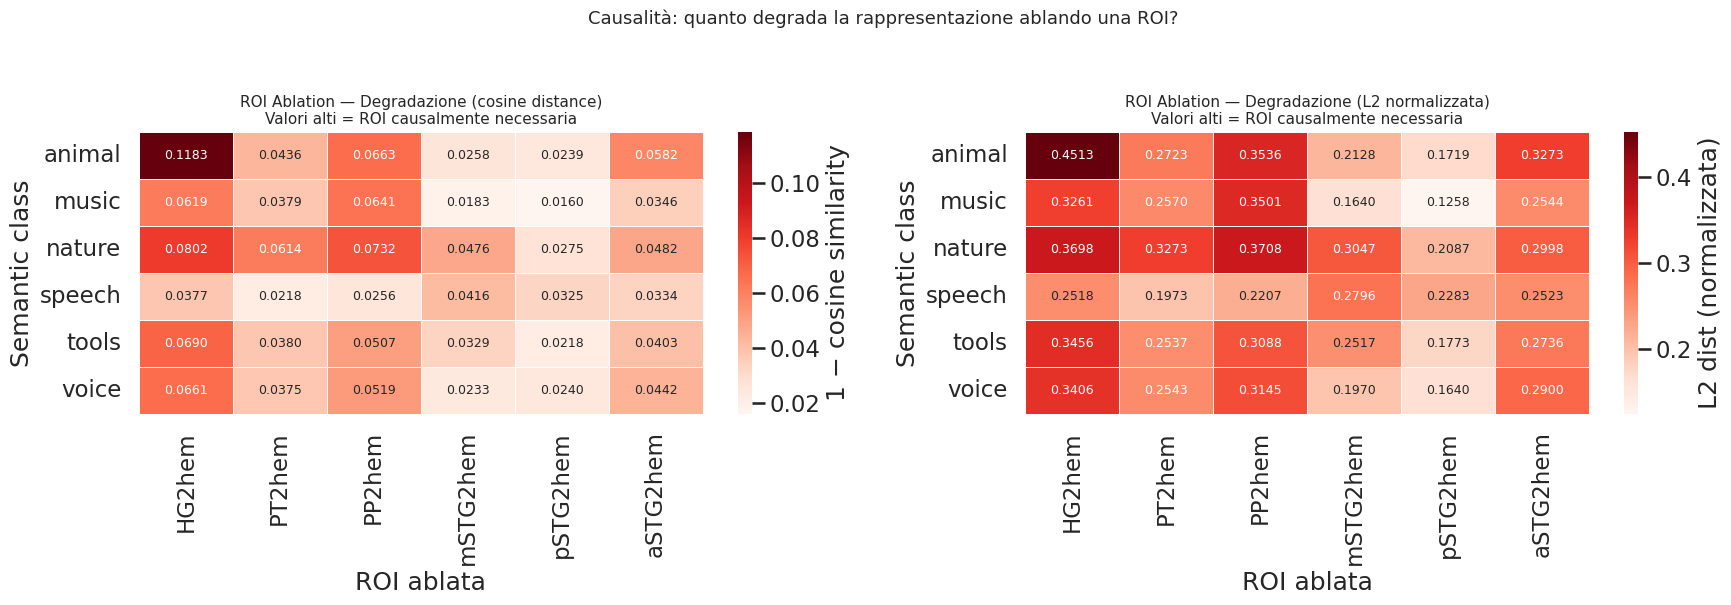

In [ ]:
# ── Aggregazione per (classe, ROI) ───────────────────────────────────────────
abl_class = ablation_df.groupby(
    ['semantic_class', 'ROI'], as_index=False
)[['cos_dist', 'l2_dist_norm']].mean()

# Pivot per heatmap
abl_cos_pivot = abl_class.pivot(index='semantic_class', columns='ROI', values='cos_dist')
abl_cos_pivot = abl_cos_pivot.loc[class_order, ROI_LIST]

abl_l2_pivot = abl_class.pivot(index='semantic_class', columns='ROI', values='l2_dist_norm')
abl_l2_pivot = abl_l2_pivot.loc[class_order, ROI_LIST]

# ── Plot: degradazione per classe × ROI ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(
    abl_cos_pivot,
    cmap='Reds',
    ax=axes[0],
    cbar_kws={'label': '1 − cosine similarity'},
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.4f',
    annot_kws={'size': 9},
)
axes[0].set_title('ROI Ablation — Degradazione (cosine distance)\nValori alti = ROI causalmente necessaria', fontsize=11)
axes[0].set_xlabel('ROI ablata')
axes[0].set_ylabel('Semantic class')

sns.heatmap(
    abl_l2_pivot,
    cmap='Reds',
    ax=axes[1],
    cbar_kws={'label': 'L2 dist (normalizzata)'},
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.4f',
    annot_kws={'size': 9},
)
axes[1].set_title('ROI Ablation — Degradazione (L2 normalizzata)\nValori alti = ROI causalmente necessaria', fontsize=11)
axes[1].set_xlabel('ROI ablata')
axes[1].set_ylabel('Semantic class')

fig.suptitle('Causalità: quanto degrada la rappresentazione ablando una ROI?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1146316/1526045086.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delta_mean = delta_trial.groupby('semantic_class')[ROI_LIST].mean().loc[class_order]


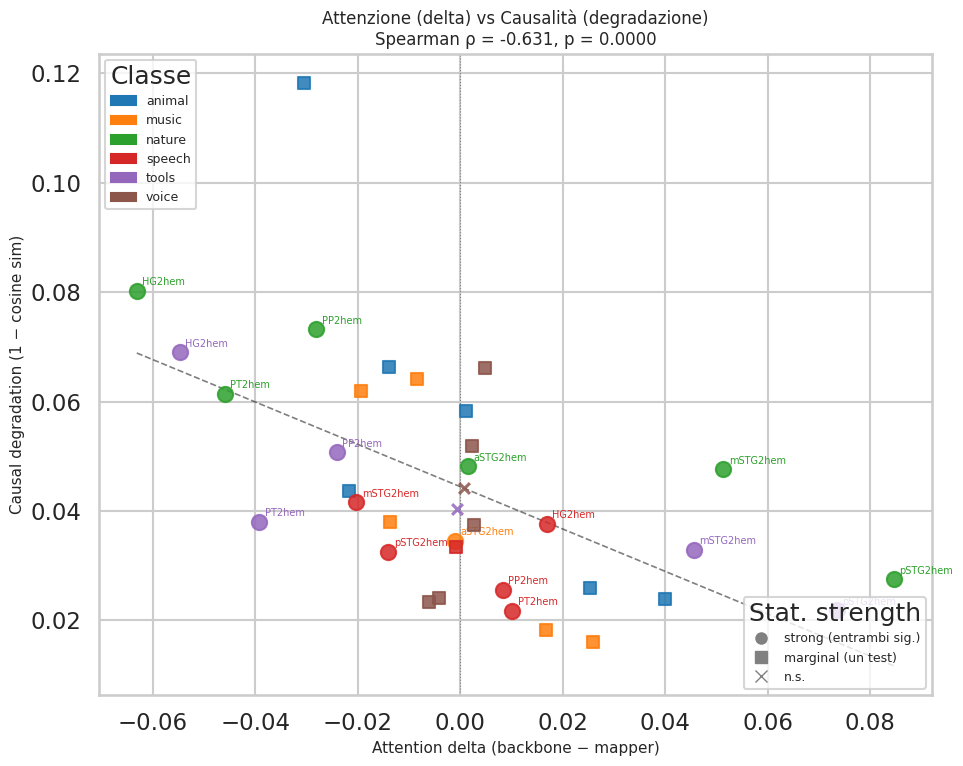


Correlazione Spearman (attenzione vs causalità): ρ = -0.631, p = 0.0000
Se ρ > 0.5 e p < 0.05: attenzione e causalità sono allineate → claim solido.


In [ ]:
# ── Confronto diretto: Attenzione (delta) vs Causalità (degradazione) ────────
# Questo è il plot chiave: se attenzione e causalità sono allineate,
# il claim è solido. Se divergono, l'attenzione è epifenomenica.

# Delta medio per classe × ROI (già calcolato)
delta_mean = delta_trial.groupby('semantic_class')[ROI_LIST].mean().loc[class_order]

# Costruisci DataFrame long per scatter
compare_rows = []
for cls in class_order:
    for r in ROI_LIST:
        compare_rows.append({
            'semantic_class': cls,
            'ROI': r,
            'attention_delta': delta_mean.loc[cls, r],
            'causal_degradation': abl_cos_pivot.loc[cls, r],
        })
compare_df = pd.DataFrame(compare_rows)

# Aggiungi significatività dal Test 1 (delta ≠ 0)
compare_df = compare_df.merge(
    df_t1[['semantic_class', 'ROI', 'significant']].rename(columns={'significant': 'sig_t1'}),
    on=['semantic_class', 'ROI'],
)
compare_df = compare_df.merge(
    df_t2[['semantic_class', 'ROI', 'significant']].rename(columns={'significant': 'sig_t2'}),
    on=['semantic_class', 'ROI'],
)
compare_df['strength'] = (
    compare_df['sig_t1'].astype(int) + compare_df['sig_t2'].astype(int)
).map({0: 'n.s.', 1: 'marginal', 2: 'strong'})

# Scatter: attention_delta (x) vs causal_degradation (y)
# Codifica colore = classe, forma = strength
fig, ax = plt.subplots(figsize=(10, 8))

markers = {'strong': 'o', 'marginal': 's', 'n.s.': 'x'}
sizes   = {'strong': 120, 'marginal': 80, 'n.s.': 60}

for cls in class_order:
    for strength, marker in markers.items():
        sub = compare_df[
            (compare_df['semantic_class'] == cls) &
            (compare_df['strength'] == strength)
        ]
        if sub.empty:
            continue
        ax.scatter(
            sub['attention_delta'],
            sub['causal_degradation'],
            color=CLASS_COLORS[cls],
            marker=marker,
            s=sizes[strength],
            alpha=0.85,
            label=f'{cls} ({strength})' if strength == 'strong' else None,
            zorder=3,
        )
        # Etichetta ROI per i punti strong
        if strength == 'strong':
            for _, row in sub.iterrows():
                ax.annotate(
                    row['ROI'],
                    (row['attention_delta'], row['causal_degradation']),
                    fontsize=7,
                    xytext=(4, 4),
                    textcoords='offset points',
                    color=CLASS_COLORS[cls],
                )

# Linea di regressione globale
from numpy.polynomial import polynomial as P
x = compare_df['attention_delta'].values
y = compare_df['causal_degradation'].values
coef = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, np.polyval(coef, x_line), 'k--', linewidth=1.2, alpha=0.5, label='regressione lineare')

# Correlazione di Spearman
from scipy.stats import spearmanr
rho, p_rho = spearmanr(x, y)
ax.set_title(
    f'Attenzione (delta) vs Causalità (degradazione)\n'
    f'Spearman ρ = {rho:.3f}, p = {p_rho:.4f}',
    fontsize=12
)
ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('Attention delta (backbone − mapper)', fontsize=11)
ax.set_ylabel('Causal degradation (1 − cosine sim)', fontsize=11)

# Legenda classi
patches = [mpatches.Patch(color=CLASS_COLORS[cls], label=cls) for cls in class_order]
legend1 = ax.legend(handles=patches, loc='upper left', title='Classe', fontsize=9)
ax.add_artist(legend1)

# Legenda forme
from matplotlib.lines import Line2D
legend2_handles = [
    Line2D([0], [0], marker='o', color='gray', linestyle='None', markersize=8, label='strong (entrambi sig.)'),
    Line2D([0], [0], marker='s', color='gray', linestyle='None', markersize=8, label='marginal (un test)'),
    Line2D([0], [0], marker='x', color='gray', linestyle='None', markersize=8, label='n.s.'),
]
ax.legend(handles=legend2_handles, loc='lower right', title='Stat. strength', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nCorrelazione Spearman (attenzione vs causalità): ρ = {rho:.3f}, p = {p_rho:.4f}')
print('Se ρ > 0.5 e p < 0.05: attenzione e causalità sono allineate → claim solido.')


=== Causal Specificity per ROI (Kruskal-Wallis, FDR) ===


/tmp/ipykernel_1146316/3505594673.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ablation_df[ablation_df['semantic_class'] == cls][ablation_df['ROI'] == r]['cos_dist'].values
/tmp/ipykernel_1146316/3505594673.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ablation_df[ablation_df['semantic_class'] == cls][ablation_df['ROI'] == r]['cos_dist'].values
/tmp/ipykernel_1146316/3505594673.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ablation_df[ablation_df['semantic_class'] == cls][ablation_df['ROI'] == r]['cos_dist'].values
/tmp/ipykernel_1146316/3505594673.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ablation_df[ablation_df['semantic_class'] == cls][ablation_df['ROI'] == r]['cos_dist'].values
/tmp/ipykernel_1146316/3505594673.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ablation_df[ablation_df['sema

'        ROI  kruskal_stat     p_raw     p_fdr  significant\n3  mSTG2hem     32.877473  0.000004  0.000012         True\n2    PP2hem     33.021689  0.000004  0.000012         True\n4  pSTG2hem     24.324962  0.000188  0.000376         True\n0    HG2hem     23.380518  0.000285  0.000428         True\n1    PT2hem     22.609209  0.000401  0.000481         True\n5  aSTG2hem     13.652968  0.017971  0.017971         True'

/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/seaborn/ax

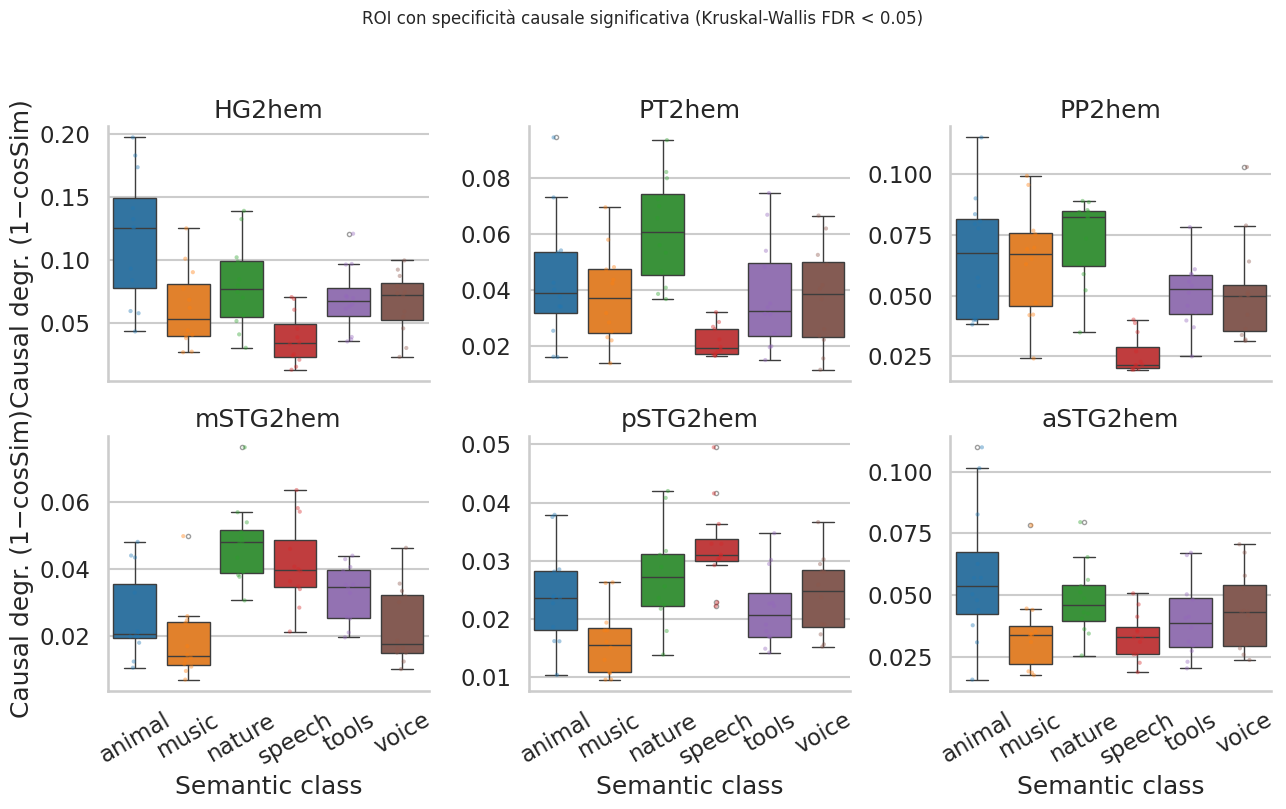

In [ ]:
# ── Causal Specificity: la degradazione è selettiva per classe? ───────────────
# Per ogni ROI: la degradazione è diversa tra classi?
# Stesso design del Test 2 ma sulla metrica causale.

from scipy.stats import kruskal

causal_spec_rows = []
for r in ROI_LIST:
    groups = [
        ablation_df[ablation_df['semantic_class'] == cls][ablation_df['ROI'] == r]['cos_dist'].values
        for cls in class_order
    ]
    # Kruskal-Wallis (non-parametrico, analogo ANOVA)
    stat, p = kruskal(*groups)
    causal_spec_rows.append({'ROI': r, 'kruskal_stat': stat, 'p_raw': p})

causal_spec_df = pd.DataFrame(causal_spec_rows)
try:
    causal_spec_df['p_fdr'] = false_discovery_control(causal_spec_df['p_raw'].values, method='bh')
except Exception:
    from statsmodels.stats.multitest import multipletests
    _, p_fdr, _, _ = multipletests(causal_spec_df['p_raw'].values, method='fdr_bh')
    causal_spec_df['p_fdr'] = p_fdr

causal_spec_df['significant'] = causal_spec_df['p_fdr'] < ALPHA

print('=== Causal Specificity per ROI (Kruskal-Wallis, FDR) ===')
display(causal_spec_df.sort_values('p_fdr').to_string())

# Boxplot per le ROI con specificità causale significativa
sig_rois = causal_spec_df[causal_spec_df['significant']]['ROI'].tolist()
if sig_rois:
    abl_sig = ablation_df[ablation_df['ROI'].isin(sig_rois)].copy()
    g = sns.FacetGrid(
        abl_sig,
        col='ROI',
        col_wrap=min(3, len(sig_rois)),
        height=4,
        aspect=1.1,
        sharey=False,
    )
    g.map_dataframe(
        sns.boxplot,
        x='semantic_class',
        y='cos_dist',
        order=class_order,
        palette='tab10',
        flierprops=dict(marker='o', markersize=3, alpha=0.5),
    )
    g.map_dataframe(
        sns.stripplot,
        x='semantic_class',
        y='cos_dist',
        order=class_order,
        palette='tab10',
        size=3,
        alpha=0.4,
        jitter=True,
    )
    g.set_axis_labels('Semantic class', 'Causal degr. (1−cosSim)')
    g.set_titles(col_template='{col_name}')
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=30)
    g.figure.suptitle(
        'ROI con specificità causale significativa (Kruskal-Wallis FDR < 0.05)',
        y=1.02, fontsize=12
    )
    plt.tight_layout()
    plt.show()
else:
    print('Nessuna ROI con specificità causale significativa dopo FDR.')


### Come leggere l'analisi causale

| Analisi | Domanda | Claim possibile |
|---|---|---|
| Heatmap degradazione | Quale ROI è necessaria per costruire la rappresentazione? | ROI con degradazione alta = causalmente rilevante |
| Scatter attenzione vs causalità | L'attenzione predice la causalità? | Se ρ > 0.5: i pattern di attenzione non sono epifenomenici |
| Kruskal-Wallis per ROI | La degradazione è selettiva per classe? | ROI significativa = il suo contributo è semanticamente specifico |

**Scenario ideale** (claim più forte pubblicabile):  
- Heatmap: le stesse ROI che mostravano delta di attenzione forti mostrano degradazione alta  
- Scatter: ρ > 0.5, p < 0.05 → attenzione e causalità allineate  
- Kruskal-Wallis: le ROI HG/PT significative per speech, mSTG/pSTG per nature/tools  

**Scenario alternativo** (ρ basso):  
Il modello presta attenzione a ROI che non sono causalmente necessarie → l'attenzione è in parte epifenomenica, claim più cauto richiesto.

> **Limite metodologico onesto**: l'ablation è fatta nel latent space dei condition tokens, non sull'audio finale. La degradazione misura quanto cambia la *rappresentazione* del cervello nel modello, non quanto cambia la *qualità percettiva* dell'audio generato. Per il secondo servirebbe generazione completa + valutazione CLAP, che è computazionalmente più costosa ma fattibile come analisi supplementare.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ROI ISOLATION  —  Sufficiency analysis
# Complementare all'ablation: invece di rimuovere una ROI, la si mantiene
# come unica sorgente e si azzera tutto il resto.
# ══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def run_roi_isolation(
    model: AudioNeuroAdapter,
    loader: DataLoader,
    sound_meta: pd.DataFrame,
):
    """
    Per ogni trial e ogni ROI:
      - forward baseline (brain integro)
      - forward isolated  (brain[:, roi_idx, :] intatta, tutto il resto = 0)
    Restituisce un DataFrame con degradazione per (sound_idx, semantic_class, ROI).

    La degradazione misura quanto la rappresentazione cambia quando il modello
    può contare SOLO su quella ROI → alta degradazione = ROI non sufficiente,
    bassa degradazione = ROI sufficiente (da sola bastava quasi tutto).
    """
    sound_meta_map = sound_meta.set_index('sound_idx')
    rows = []

    for batch_idx, batch in enumerate(loader):
        brain     = batch['brain_data'].to(device)    # (B, n_rois, n_voxels)
        sound_idx = batch['sound_idx'].cpu().numpy()
        B = brain.shape[0]

        # Baseline: forward con brain integro
        tokens_baseline, _ = model.guidance_generator(brain)
        tokens_baseline = tokens_baseline.detach()

        # Isolation: mantieni una ROI alla volta
        for roi_idx, roi_name in enumerate(ROI_LIST):
            brain_iso = torch.zeros_like(brain)
            brain_iso[:, roi_idx, :] = brain[:, roi_idx, :]

            tokens_iso, _ = model.guidance_generator(brain_iso)
            tokens_iso = tokens_iso.detach()

            cos_sim  = F.cosine_similarity(tokens_baseline, tokens_iso, dim=-1)
            cos_dist = (1.0 - cos_sim).mean(dim=-1)

            l2_dist = (
                (tokens_baseline - tokens_iso).norm(dim=-1).mean(dim=-1)
                / tokens_baseline.norm(dim=-1).mean(dim=-1).clamp(min=1e-8)
            )

            for i in range(B):
                meta = sound_meta_map.loc[int(sound_idx[i])]
                rows.append({
                    'sound_idx':      int(sound_idx[i]),
                    'sound_name':     meta['sound_name'],
                    'semantic_class': meta['semantic_class'],
                    'ROI':            roi_name,
                    'cos_dist':       float(cos_dist[i].item()),
                    'l2_dist_norm':   float(l2_dist[i].item()),
                })

        if (batch_idx + 1) % 5 == 0:
            print(f'  Isolation batch {batch_idx + 1}/{len(loader)}')

    return pd.DataFrame(rows)


print('Avvio isolation (keep-one-ROI)...')
isolation_df = run_roi_isolation(model, loader, sound_meta)
print(f'Done. Righe: {len(isolation_df)}')

Avvio isolation (keep-one-ROI)...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Isolation batch 5/18
  Isolation batch 10/18
  Isolation batch 15/18
Done. Righe: 432


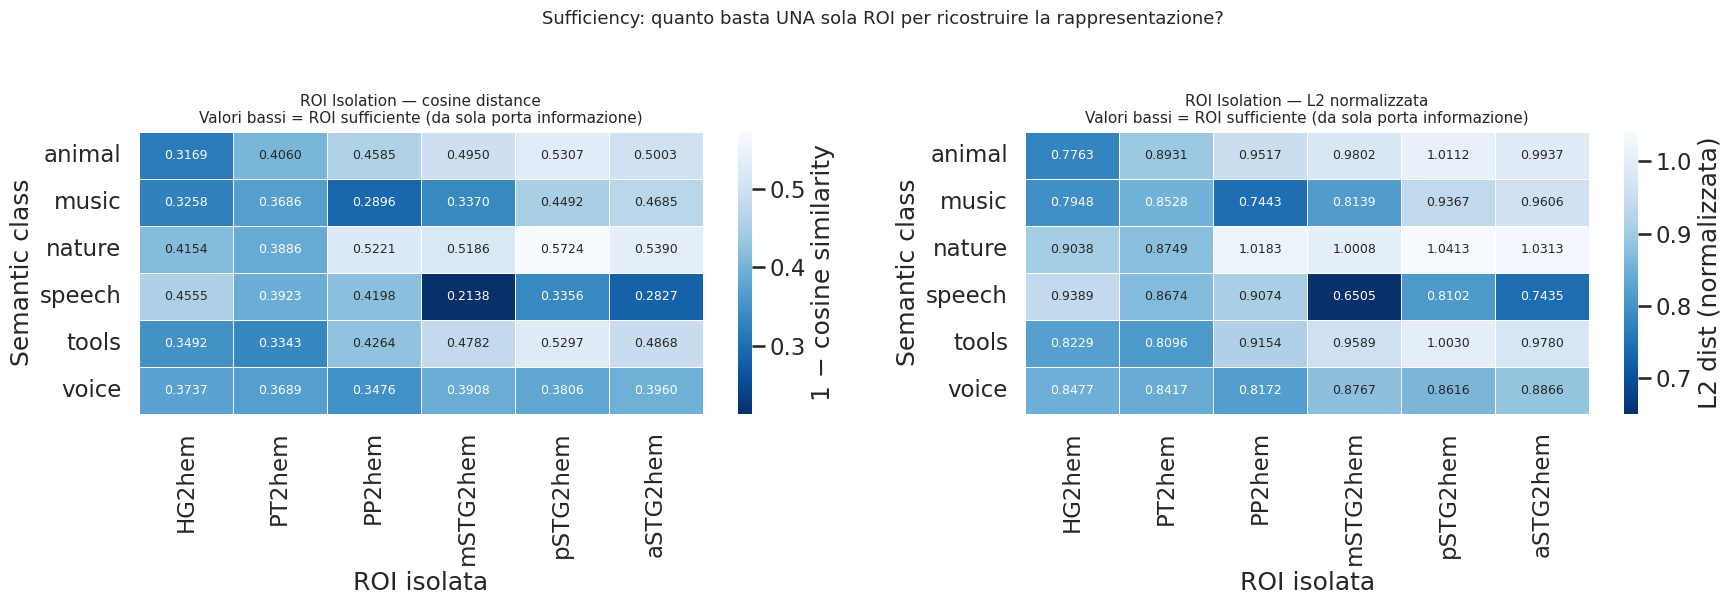

In [ ]:
# ── Heatmap isolation: degradazione per classe × ROI ─────────────────────────

iso_class = isolation_df.groupby(
    ['semantic_class', 'ROI'], as_index=False
)[['cos_dist', 'l2_dist_norm']].mean()

iso_cos_pivot = iso_class.pivot(index='semantic_class', columns='ROI', values='cos_dist')
iso_cos_pivot = iso_cos_pivot.loc[class_order, ROI_LIST]

iso_l2_pivot = iso_class.pivot(index='semantic_class', columns='ROI', values='l2_dist_norm')
iso_l2_pivot = iso_l2_pivot.loc[class_order, ROI_LIST]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, pivot, cbar_label, title_suffix in zip(
    axes,
    [iso_cos_pivot, iso_l2_pivot],
    ['1 − cosine similarity', 'L2 dist (normalizzata)'],
    ['cosine distance', 'L2 normalizzata'],
):
    sns.heatmap(
        pivot,
        cmap='Blues_r',       # invertita: bassa degradazione = ROI sufficiente = colore intenso
        ax=ax,
        cbar_kws={'label': cbar_label},
        linewidths=0.4,
        linecolor='white',
        annot=True,
        fmt='.4f',
        annot_kws={'size': 9},
    )
    ax.set_title(
        f'ROI Isolation — {title_suffix}\n'
        f'Valori bassi = ROI sufficiente (da sola porta informazione)',
        fontsize=11
    )
    ax.set_xlabel('ROI isolata')
    ax.set_ylabel('Semantic class')

fig.suptitle('Sufficiency: quanto basta UNA sola ROI per ricostruire la rappresentazione?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── Scatter attenzione vs causalità: necessity E sufficiency a confronto ──────

# Prepara sufficiency long-form (stessa struttura di compare_df)
iso_compare_rows = []
for cls in class_order:
    for r in ROI_LIST:
        iso_compare_rows.append({
            'semantic_class': cls,
            'ROI': r,
            'attention_delta':    delta_mean.loc[cls, r],
            'suff_degradation':   iso_cos_pivot.loc[cls, r],
        })
iso_compare_df = pd.DataFrame(iso_compare_rows)

# Aggiungi significatività dai test precedenti
iso_compare_df = iso_compare_df.merge(
    df_t1[['semantic_class', 'ROI', 'significant']].rename(columns={'significant': 'sig_t1'}),
    on=['semantic_class', 'ROI'],
)
iso_compare_df = iso_compare_df.merge(
    df_t2[['semantic_class', 'ROI', 'significant']].rename(columns={'significant': 'sig_t2'}),
    on=['semantic_class', 'ROI'],
)
iso_compare_df['strength'] = (
    iso_compare_df['sig_t1'].astype(int) + iso_compare_df['sig_t2'].astype(int)
).map({0: 'n.s.', 1: 'marginal', 2: 'strong'})

# ── Plot a due pannelli: necessity (ablation) | sufficiency (isolation) ───────
from scipy.stats import spearmanr



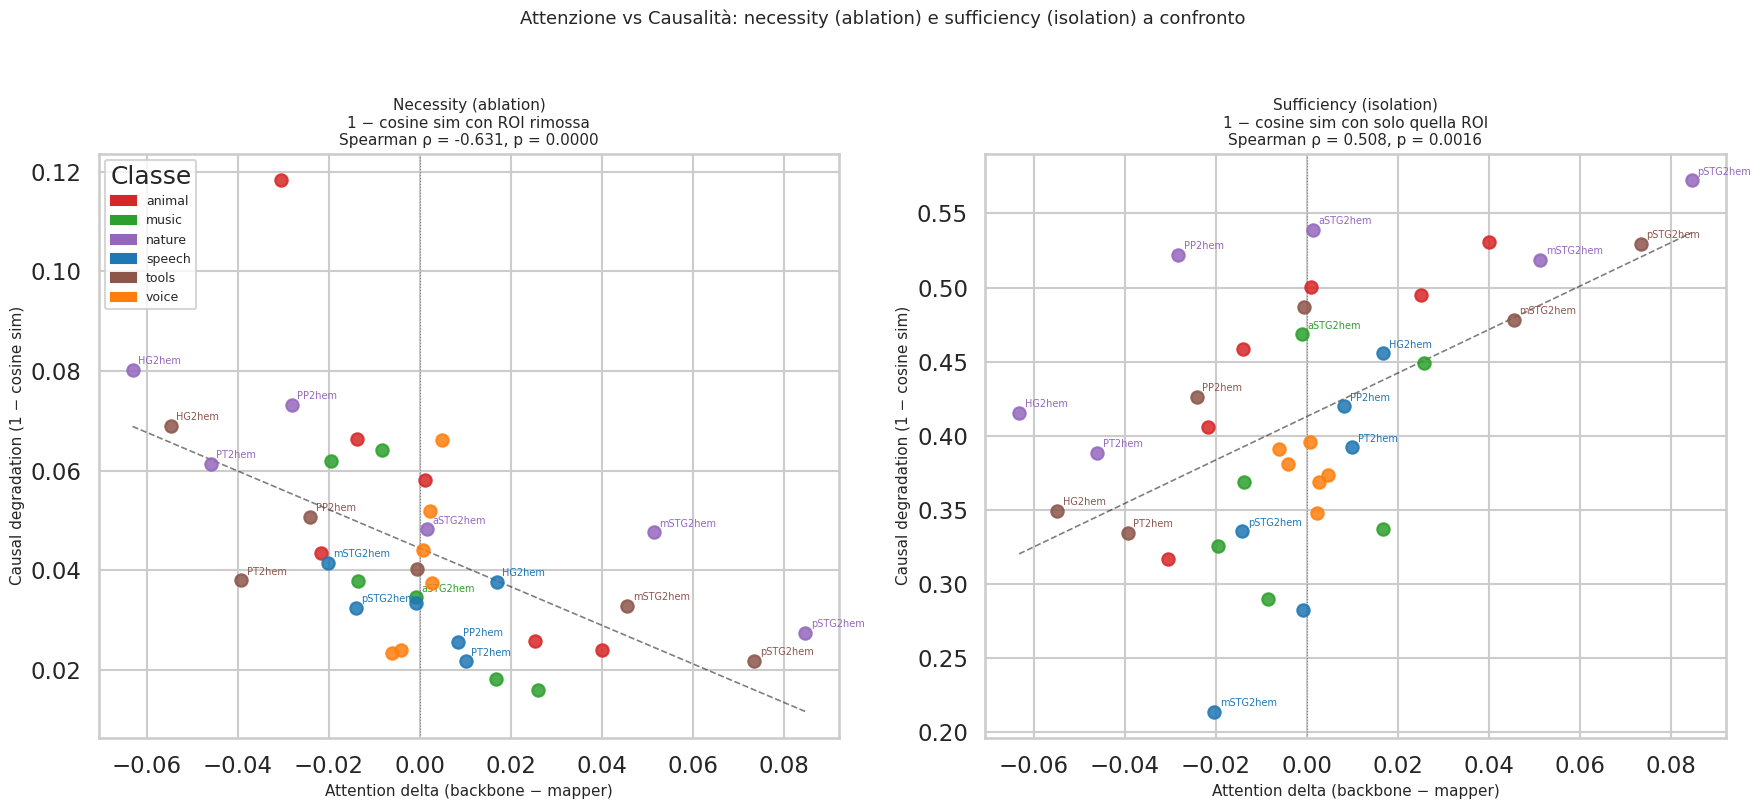

Necessity (ablation): ρ = -0.631, p = 0.0000
Sufficiency (isolation): ρ = 0.508, p = 0.0016


In [ ]:
# ── Token space ───────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

for ax, (df, y_col, y_label) in zip(axes, [
    (compare_df,     'causal_degradation', 'Necessity (ablation)\n1 − cosine sim con ROI rimossa'),
    (iso_compare_df, 'suff_degradation',   'Sufficiency (isolation)\n1 − cosine sim con solo quella ROI'),
]):
    for cls in class_order:
        sub = df[df['semantic_class'] == cls]
        if sub.empty:
            continue
        ax.scatter(
            sub['attention_delta'],
            sub[y_col],
            color=CLASS_COLORS[cls],
            marker='o',
            s=80,
            alpha=0.85,
            zorder=3,
        )
        for _, row in sub[sub['strength'] == 'strong'].iterrows():
            ax.annotate(
                row['ROI'],
                (row['attention_delta'], row[y_col]),
                fontsize=7, xytext=(4, 4),
                textcoords='offset points',
                color=CLASS_COLORS[cls],
            )

    x, y = df['attention_delta'].values, df[y_col].values
    coef = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, np.polyval(coef, x_line), 'k--', linewidth=1.2, alpha=0.5)

    rho, p_rho = spearmanr(x, y)
    ax.set_title(f'{y_label}\nSpearman ρ = {rho:.3f}, p = {p_rho:.4f}', fontsize=11)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Attention delta (backbone − mapper)', fontsize=11)
    ax.set_ylabel('Causal degradation (1 − cosine sim)', fontsize=11)

patches = [mpatches.Patch(color=CLASS_COLORS[cls], label=cls) for cls in class_order]
axes[0].legend(handles=patches, loc='upper left', title='Classe', fontsize=9)

fig.suptitle(
    'Attenzione vs Causalità: necessity (ablation) e sufficiency (isolation) a confronto',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

for df, y_col, label in [
    (compare_df,     'causal_degradation', 'Necessity (ablation)'),
    (iso_compare_df, 'suff_degradation',   'Sufficiency (isolation)'),
]:
    rho, p = spearmanr(df['attention_delta'].values, df[y_col].values)
    print(f'{label}: ρ = {rho:.3f}, p = {p:.4f}')

## Cusality on Generation

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# AUDIO-SPACE CAUSALITY  —  Necessity & Sufficiency con Mel spettrogramma
# ══════════════════════════════════════════════════════════════════════════════

import re
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import spearmanr

# ── Configurazione ────────────────────────────────────────────────────────────
BASE        = Path('/srv/nfs-data/sisko/matteoc/maas_2023')
FULL_DIR    = BASE / 'decoded_ip2'
ROI_DIR     = BASE / 'decoded_roi_subset'
SOUND_NAMES = np.load(
    '/home/matteoc/brainSounds/maas_data/SoundNames.npy', allow_pickle=True
)

TARGET_SR      = 48000
MEL_N_FFT      = 1024
MEL_HOP_LENGTH = 256
MEL_N_MELS     = 64
MEL_FMAX       = 8000

DEVICE = torch.device('cuda:6' if torch.cuda.is_available() else 'cpu')

ROI_LIST_AUDIO = ['HG2hem', 'PT2hem', 'PP2hem', 'mSTG2hem', 'pSTG2hem', 'aSTG2hem']
CLASS_ORDER    = ['speech', 'voice', 'music', 'animal', 'nature', 'tools']
CLASS_COLORS   = {
    cls: color for cls, color in zip(
        CLASS_ORDER, sns.color_palette('tab10', len(CLASS_ORDER))
    )
}

print('Device:', DEVICE)

Device: cuda:6


In [ ]:
# ── Metadati sound names ──────────────────────────────────────────────────────

def parse_semantic_class(name: str) -> str:
    m = re.match(r'stim\d+_cat\d+_([a-zA-Z]+)_exemp\d+', str(name))
    return m.group(1).lower() if m else 'unknown'

sound_meta = pd.DataFrame({
    'sound_idx':      range(len(SOUND_NAMES)),
    'sound_name':     [str(n) for n in SOUND_NAMES],
    'semantic_class': [parse_semantic_class(n) for n in SOUND_NAMES],
})
meta_map = dict(zip(sound_meta['sound_name'], sound_meta['semantic_class']))

print(sound_meta['semantic_class'].value_counts().sort_index())

semantic_class
animal    48
music     48
nature    48
speech    48
tools     48
voice     48
Name: count, dtype: int64


In [ ]:
# ── Mel transform e funzione di embedding ────────────────────────────────────

mel_transform = T.MelSpectrogram(
    sample_rate=TARGET_SR,
    n_fft=MEL_N_FFT,
    hop_length=MEL_HOP_LENGTH,
    n_mels=MEL_N_MELS,
    f_max=MEL_FMAX,
).to(DEVICE)

@torch.no_grad()
def mel_embed(wav_path: Path) -> torch.Tensor:
    """
    Carica un file wav e restituisce il log-mel spettrogramma mediato nel tempo.
    La media temporale rimuove la sensibilità all'allineamento temporale.
    Output: vettore normalizzato (n_mels,) su CPU.
    """
    waveform, sr = torchaudio.load(wav_path)
    if sr != TARGET_SR:
        waveform = torchaudio.functional.resample(waveform, sr, TARGET_SR)
    waveform = waveform.mean(0, keepdim=True).to(DEVICE)   # mono (1, T)
    mel      = mel_transform(waveform)                      # (1, n_mels, T)
    log_mel  = torch.log(mel + 1e-6)
    descriptor = log_mel.mean(dim=-1).squeeze(0)            # (n_mels,)
    return F.normalize(descriptor, dim=-1).cpu()

In [129]:
# ── Mappa file: sound_name → path ────────────────────────────────────────────

def build_file_map(directory: Path) -> dict:
    """
    Funzione generica che funziona sia per:
      gt_sound{IDX}_sample{IDX}.wav
      pred_keep_*_sound{IDX}_sample{IDX}.wav
    """
    file_map = {}
    for f in sorted(directory.glob('*.wav')):
        m = re.search(r'sound(\d+)_sample\d+\.wav', f.name)
        if m:
            idx = int(m.group(1))
            if idx < len(SOUND_NAMES):
                file_map[str(SOUND_NAMES[idx])] = f
    return file_map

full_map  = build_file_map(FULL_DIR)
only_maps = {}
no_maps   = {}

for d in sorted(ROI_DIR.iterdir()):
    if not d.is_dir():
        continue
    if d.name.startswith('only_'):
        roi = d.name.replace('only_', '')
        only_maps[roi] = build_file_map(d)
    elif d.name.startswith('no_'):
        roi = d.name.replace('no_', '')
        no_maps[roi]   = build_file_map(d)

print(f'Full model:  {len(full_map)} file')
for roi, m in no_maps.items():
    print(f'  no_{roi}:   {len(m)} file')
for roi, m in only_maps.items():
    print(f'  only_{roi}: {len(m)} file')

Full model:  72 file
  no_HG2hem:   72 file
  no_PP2hem:   72 file
  no_PT2hem:   72 file
  no_aSTG2hem:   72 file
  no_mSTG2hem:   72 file
  no_pSTG2hem:   72 file
  only_HG2hem: 72 file
  only_PP2hem: 72 file
  only_PT2hem: 72 file
  only_aSTG2hem: 72 file
  only_acoustic: 72 file
  only_mSTG2hem: 72 file
  only_pSTG2hem: 72 file
  only_semantic: 72 file


In [130]:
# ── Calcolo embeddings Mel per tutte le condizioni ───────────────────────────

def embed_all(file_maps: dict) -> dict:
    """Restituisce {roi: {sound_name: embedding}}."""
    result = {}
    for roi, fmap in file_maps.items():
        result[roi] = {sname: mel_embed(path) for sname, path in fmap.items()}
        print(f'  {roi}: {len(result[roi])} embedding')
    return result

print('Full model...')
full_emb = {sname: mel_embed(path) for sname, path in full_map.items()}

print('Necessity (no_*)...')
no_emb   = embed_all(no_maps)

print('Sufficiency (only_*)...')
only_emb = embed_all(only_maps)

print('Done.')

Full model...
Necessity (no_*)...
  HG2hem: 72 embedding
  PP2hem: 72 embedding
  PT2hem: 72 embedding
  aSTG2hem: 72 embedding
  mSTG2hem: 72 embedding
  pSTG2hem: 72 embedding
Sufficiency (only_*)...
  HG2hem: 72 embedding
  PP2hem: 72 embedding
  PT2hem: 72 embedding
  aSTG2hem: 72 embedding
  acoustic: 72 embedding
  mSTG2hem: 72 embedding
  pSTG2hem: 72 embedding
  semantic: 72 embedding
Done.


In [131]:
# ── Costruisci DataFrame degradazione ────────────────────────────────────────

def build_degradation_df(cond_embeddings: dict,
                          ref_embeddings: dict,
                          cond_type: str) -> pd.DataFrame:
    rows = []
    for roi, emb_map in cond_embeddings.items():
        for sname, emb_cond in emb_map.items():
            if sname not in ref_embeddings:
                continue
            cos_sim  = F.cosine_similarity(
                ref_embeddings[sname].unsqueeze(0),
                emb_cond.unsqueeze(0)
            ).item()
            rows.append({
                'sound_name':     sname,
                'semantic_class': meta_map.get(sname, 'unknown'),
                'ROI':            roi,
                'cos_dist':       1 - cos_sim,
                'cond_type':      cond_type,
            })
    return pd.DataFrame(rows)

nec_df  = build_degradation_df(no_emb,   full_emb, 'necessity')
suff_df = build_degradation_df(only_emb, full_emb, 'sufficiency')

# Filtra solo le ROI anatomiche (esclude only_acoustic, only_semantic)
nec_df  = nec_df[nec_df['ROI'].isin(ROI_LIST_AUDIO)]
suff_df = suff_df[suff_df['ROI'].isin(ROI_LIST_AUDIO)]

print('Necessity rows: ', len(nec_df))
print('Sufficiency rows:', len(suff_df))

Necessity rows:  432
Sufficiency rows: 432


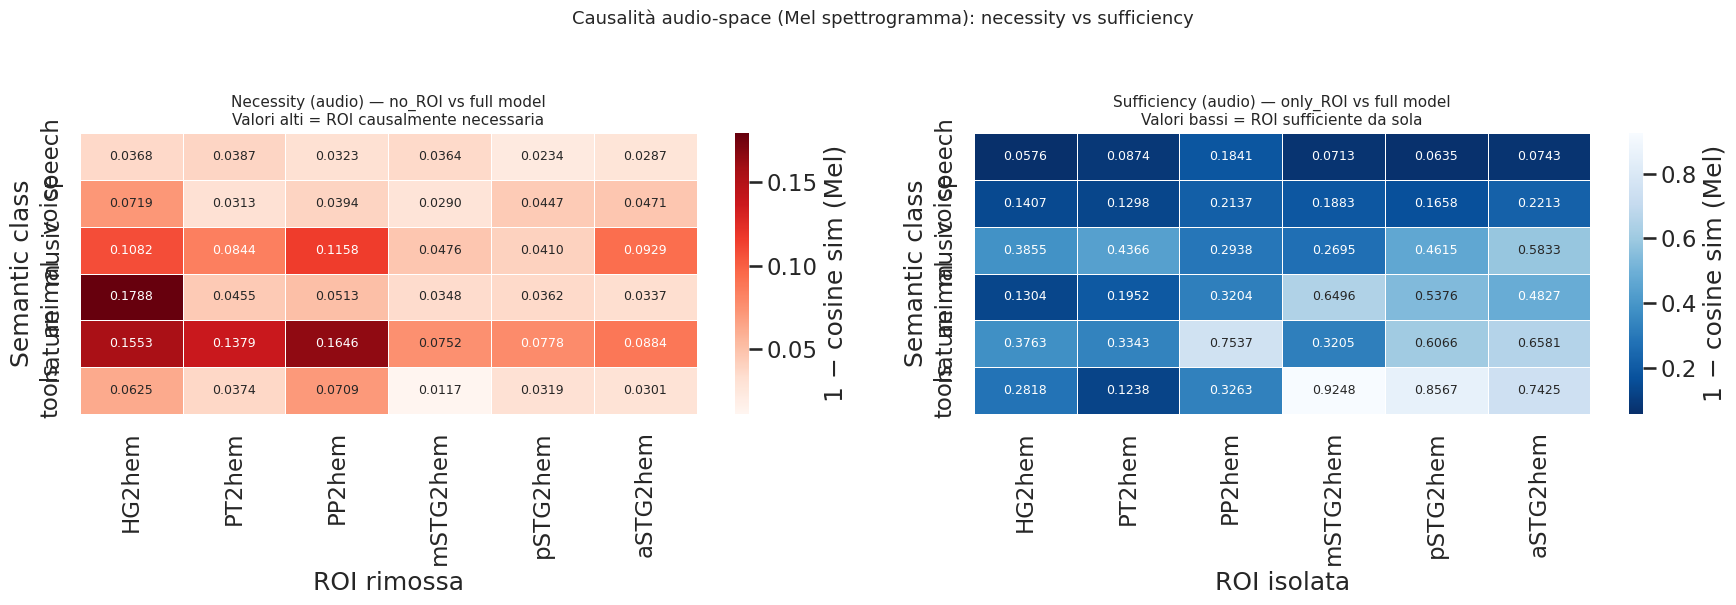

In [132]:
# ── Pivot per heatmap ─────────────────────────────────────────────────────────

nec_pivot  = (nec_df
              .groupby(['semantic_class', 'ROI'])['cos_dist']
              .mean()
              .unstack()
              .loc[CLASS_ORDER, ROI_LIST_AUDIO])

suff_pivot = (suff_df
              .groupby(['semantic_class', 'ROI'])['cos_dist']
              .mean()
              .unstack()
              .loc[CLASS_ORDER, ROI_LIST_AUDIO])

# ── Heatmap necessity e sufficiency ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(
    nec_pivot, cmap='Reds', ax=axes[0],
    annot=True, fmt='.4f', annot_kws={'size': 9},
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': '1 − cosine sim (Mel)'},
)
axes[0].set_title(
    'Necessity (audio) — no_ROI vs full model\n'
    'Valori alti = ROI causalmente necessaria',
    fontsize=11
)
axes[0].set_xlabel('ROI rimossa')
axes[0].set_ylabel('Semantic class')

sns.heatmap(
    suff_pivot, cmap='Blues_r', ax=axes[1],
    annot=True, fmt='.4f', annot_kws={'size': 9},
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': '1 − cosine sim (Mel)'},
)
axes[1].set_title(
    'Sufficiency (audio) — only_ROI vs full model\n'
    'Valori bassi = ROI sufficiente da sola',
    fontsize=11
)
axes[1].set_xlabel('ROI isolata')
axes[1].set_ylabel('Semantic class')

fig.suptitle(
    'Causalità audio-space (Mel spettrogramma): necessity vs sufficiency',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

In [133]:
from scipy.stats import pearsonr

# ── Helper scatter ────────────────────────────────────────────────────────────
# Riusa delta_mean, df_t1, df_t2 dalla sezione Statistics del notebook.

markers = {'strong': 'o', 'marginal': 's', 'n.s.': 'x'}
sizes   = {'strong': 120, 'marginal': 80, 'n.s.': 60}

def build_compare_df(deg_pivot: pd.DataFrame, y_col: str) -> pd.DataFrame:
    """Allinea la degradazione audio con attention delta e significatività."""
    rows = []
    for cls in CLASS_ORDER:
        if cls not in deg_pivot.index:
            continue
        for r in ROI_LIST_AUDIO:
            if r not in deg_pivot.columns or r not in ROI_LIST:
                continue
            if cls not in delta_mean.index:
                continue
            rows.append({
                'semantic_class': cls,
                'ROI':            r,
                'attention_delta': delta_mean.loc[cls, r],
                y_col:             deg_pivot.loc[cls, r],
            })
    df = pd.DataFrame(rows).dropna()
    df = df.merge(
        df_t1[['semantic_class', 'ROI', 'significant']].rename(
            columns={'significant': 'sig_t1'}),
        on=['semantic_class', 'ROI'], how='left',
    )
    df = df.merge(
        df_t2[['semantic_class', 'ROI', 'significant']].rename(
            columns={'significant': 'sig_t2'}),
        on=['semantic_class', 'ROI'], how='left',
    )
    df['strength'] = (
        df['sig_t1'].fillna(False).astype(int) +
        df['sig_t2'].fillna(False).astype(int)
    ).map({0: 'n.s.', 1: 'marginal', 2: 'strong'})
    return df


def scatter_attn_vs_causal(ax, df, y_col, y_label, title):
    for cls in CLASS_ORDER:
        sub = df[df['semantic_class'] == cls]
        if sub.empty:
            continue
        ax.scatter(
            sub['attention_delta'], sub[y_col],
            color=CLASS_COLORS[cls], marker='o',
            s=80, alpha=0.85, zorder=3,
        )
        for _, row in sub[sub['strength'] == 'strong'].iterrows():
            ax.annotate(
                row['ROI'],
                (row['attention_delta'], row[y_col]),
                fontsize=7, xytext=(4, 4),
                textcoords='offset points',
                color=CLASS_COLORS[cls],
            )

    x, y = df['attention_delta'].values, df[y_col].values
    coef = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, np.polyval(coef, x_line), 'k--', lw=1.2, alpha=0.5)

    rho, p = pearsonr(x, y)
    ax.set_title(f'{title}\nSpearman ρ = {rho:.3f}, p = {p:.4f}', fontsize=11)
    ax.axvline(0, color='gray', lw=0.8, ls=':')
    ax.set_xlabel('Attention delta (backbone − mapper)', fontsize=11)
    ax.set_ylabel('1 − cosine sim Mel', fontsize=11)
    return rho, p


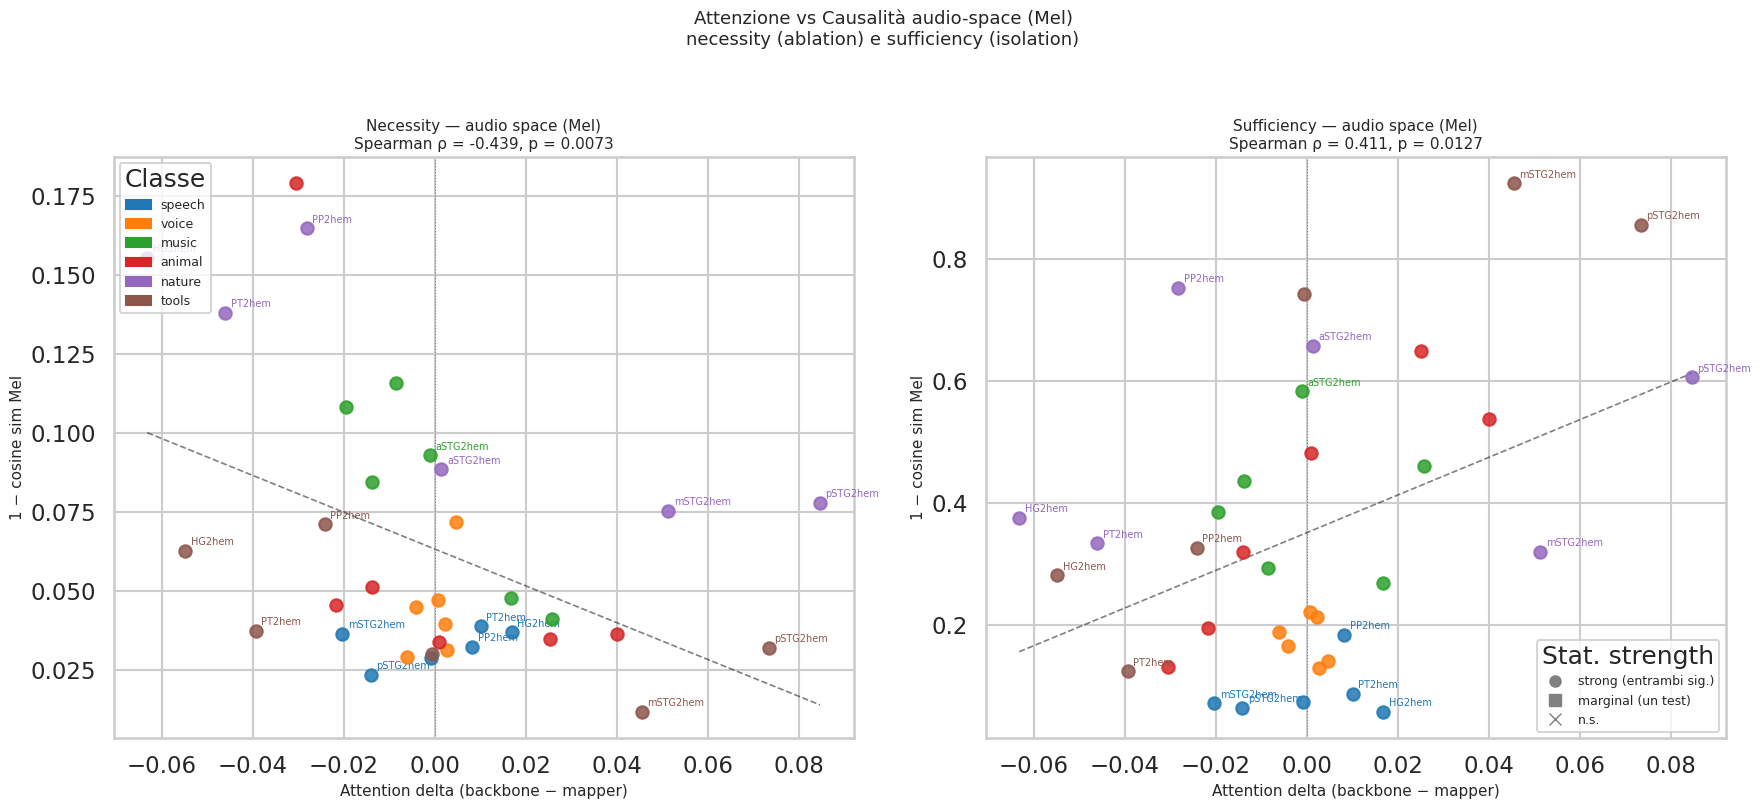

Necessity  audio Mel: ρ = -0.439,  p = 0.0073
Sufficiency audio Mel: ρ = 0.411, p = 0.0127


In [134]:
# ── Scatter necessity e sufficiency (audio space) ────────────────────────────

nec_compare  = build_compare_df(nec_pivot,  'nec_mel')
suff_compare = build_compare_df(suff_pivot, 'suff_mel')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

rho_nec,  p_nec  = scatter_attn_vs_causal(
    axes[0], nec_compare,  'nec_mel',
    '1 − cosine sim Mel (no_ROI vs full)',
    'Necessity — audio space (Mel)',
)
rho_suff, p_suff = scatter_attn_vs_causal(
    axes[1], suff_compare, 'suff_mel',
    '1 − cosine sim Mel (only_ROI vs full)',
    'Sufficiency — audio space (Mel)',
)

patches = [mpatches.Patch(color=CLASS_COLORS[cls], label=cls)
           for cls in CLASS_ORDER]
legend2 = [
    Line2D([0],[0], marker='o', color='gray', ls='None', ms=8,
           label='strong (entrambi sig.)'),
    Line2D([0],[0], marker='s', color='gray', ls='None', ms=8,
           label='marginal (un test)'),
    Line2D([0],[0], marker='x', color='gray', ls='None', ms=8,
           label='n.s.'),
]
axes[0].legend(handles=patches, loc='upper left', title='Classe', fontsize=9)
axes[1].legend(handles=legend2, loc='lower right', title='Stat. strength', fontsize=9)

fig.suptitle(
    'Attenzione vs Causalità audio-space (Mel)\n'
    'necessity (ablation) e sufficiency (isolation)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

print(f'Necessity  audio Mel: ρ = {rho_nec:.3f},  p = {p_nec:.4f}')
print(f'Sufficiency audio Mel: ρ = {rho_suff:.3f}, p = {p_suff:.4f}')